Inserimento della rete dell'isola d'Elba creata con PyPSA Distribution

In [ ]:
import pypsa
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pypsa.plot import add_legend_circles

n= pypsa.Network("n_connected (2).nc")

n.determine_network_topology()




# Calcolo tensioni lato trasformatore
for b in ["0", "1"]:
    n.transformers["v"+b] = n.transformers["bus"+b].map(n.buses.v_nom)

MODIFICO LA RETE CON I NUOVI CONDUTTORI E OTTENGO UNA NUOVA RETE CHIAMATA n_mod

In [2]:
import pypsa
import numpy as np
import pandas as pd

# 1 Parto dalla rete base

n_mod = n.copy()

# 2 Definisco i nuovi tipi di linea per MT e AT

mt_type = "122-AL1/20-ST1A 20.0_custom"

if mt_type not in n_mod.line_types.index:
    n_mod.line_types.loc[mt_type, "f_nom"] = 50.0
    n_mod.line_types.loc[mt_type, "r_per_length"] = 0.253
    n_mod.line_types.loc[mt_type, "x_per_length"] = 0.330
    n_mod.line_types.loc[mt_type, "c_per_length"] = 11.0   # nF/km
    n_mod.line_types.loc[mt_type, "i_nom"] = 0.45          # kA
    n_mod.line_types.loc[mt_type, "mounting"] = "ol"
    n_mod.line_types.loc[mt_type, "cross_section"] = 122.0

#  AT: 132 kV
at_type = "184-AL1/30-ST1A 110.0_custom"

if at_type not in n_mod.line_types.index:
    n_mod.line_types.loc[at_type, "f_nom"] = 50.0
    n_mod.line_types.loc[at_type, "r_per_length"] = 0.1571
    n_mod.line_types.loc[at_type, "x_per_length"] = 0.4000
    n_mod.line_types.loc[at_type, "c_per_length"] = 8.80   # nF/km
    n_mod.line_types.loc[at_type, "i_nom"] = 0.535         # kA
    n_mod.line_types.loc[at_type, "mounting"] = "ol"
    n_mod.line_types.loc[at_type, "cross_section"] = 184.0


# 3 Funzione di aggiornamento linee

def update_lines(n_mod, voltage_level_kv, new_type):
    r_per_km = float(n_mod.line_types.loc[new_type, "r_per_length"])
    x_per_km = float(n_mod.line_types.loc[new_type, "x_per_length"])
    i_nom = float(n_mod.line_types.loc[new_type, "i_nom"])
    f_nom = float(n_mod.line_types.loc[new_type, "f_nom"])

    c_per_length = n_mod.line_types.loc[new_type, "c_per_length"]
    c_per_length = float(c_per_length) if pd.notna(c_per_length) else 0.0

    # S nominale trifase [MVA]
    s_nom_mva = np.sqrt(3) * voltage_level_kv * i_nom

    bus0_v = n_mod.lines.bus0.map(n_mod.buses.v_nom)
    bus1_v = n_mod.lines.bus1.map(n_mod.buses.v_nom)

    # prendo solo linee i cui due estremi stanno a quel livello
    mask = (bus0_v == voltage_level_kv) & (bus1_v == voltage_level_kv)
    lines_to_update = n_mod.lines.index[mask]

    print(f"Linee {voltage_level_kv:.0f} kV da aggiornare: {len(lines_to_update)}")

    for line in lines_to_update:
        length_km = n_mod.lines.at[line, "length"]

        if pd.isna(length_km) or length_km <= 0:
            length_km = 1.0

        n_mod.lines.at[line, "type"] = new_type
        n_mod.lines.at[line, "r"] = r_per_km * length_km
        n_mod.lines.at[line, "x"] = x_per_km * length_km

        # b totale da c_per_length [nF/km]
        b_per_km = 2 * np.pi * f_nom * (c_per_length * 1e-9)
        n_mod.lines.at[line, "b"] = b_per_km * length_km

        n_mod.lines.at[line, "s_nom"] = s_nom_mva

    return lines_to_update, s_nom_mva


# 4 Aggiorno tutti i livelli

lines_15, s15 = update_lines(n_mod, 15.0, mt_type)
lines_30, s30 = update_lines(n_mod, 30.0, mt_type)
lines_132, s132 = update_lines(n_mod, 132.0, at_type)

# 5 Controllo risultati
print("\nAggiornamento completato.")
print(f"s_nom linee 15 kV  = {s15:.3f} MVA")
print(f"s_nom linee 30 kV  = {s30:.3f} MVA")
print(f"s_nom linee 132 kV = {s132:.3f} MVA")

print("\nTipi di linea presenti dopo l'aggiornamento:")
print(n_mod.lines["type"].value_counts())

print("\nControllo linee 15 kV:")
display(n_mod.lines.loc[lines_15, ["bus0", "bus1", "v_nom", "length", "type", "r", "x", "b", "s_nom"]].head())

print("\nControllo linee 30 kV:")
display(n_mod.lines.loc[lines_30, ["bus0", "bus1", "v_nom", "length", "type", "r", "x", "b", "s_nom"]].head())

print("\nControllo linee 132 kV:")
display(n_mod.lines.loc[lines_132, ["bus0", "bus1", "v_nom", "length", "type", "r", "x", "b", "s_nom"]])

print("\nLinee con s_nom = 0:", (n_mod.lines.s_nom == 0).sum())


# 6. Salvo la rete finale

output_file = "n_connected_MT_AT_upgrade.nc"
n_mod.export_to_netcdf(output_file)
print(f"\nFile salvato come: {output_file}")

c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incom

Linee 15 kV da aggiornare: 170
Linee 30 kV da aggiornare: 5
Linee 132 kV da aggiornare: 3

Aggiornamento completato.
s_nom linee 15 kV  = 11.691 MVA
s_nom linee 30 kV  = 23.383 MVA
s_nom linee 132 kV = 122.317 MVA

Tipi di linea presenti dopo l'aggiornamento:
type
122-AL1/20-ST1A 20.0_custom     175
184-AL1/30-ST1A 110.0_custom      3
Name: count, dtype: int64

Controllo linee 15 kV:


,bus0,bus1,v_nom,length,type,r,x,b,s_nom
Line,,,,,,,,,
0,microgrid_1_bus_0,microgrid_1_bus_126,15.0,0.568591,122-AL1/20-ST1A 20.0_custom,0.143853,0.187635,0.000002,11.691343
1,microgrid_1_bus_1,microgrid_1_bus_127,15.0,1.906614,122-AL1/20-ST1A 20.0_custom,0.482373,0.629183,0.000007,11.691343
2,microgrid_1_bus_2,microgrid_1_bus_16,15.0,0.705890,122-AL1/20-ST1A 20.0_custom,0.178590,0.232944,0.000002,11.691343
5,microgrid_1_bus_7,microgrid_1_bus_74,15.0,2.246672,122-AL1/20-ST1A 20.0_custom,0.568408,0.741402,0.000008,11.691343
6,microgrid_1_bus_11,microgrid_1_bus_73,15.0,0.863542,122-AL1/20-ST1A 20.0_custom,0.218476,0.284969,0.000003,11.691343



Controllo linee 30 kV:


,bus0,bus1,v_nom,length,type,r,x,b,s_nom
Line,,,,,,,,,
3,microgrid_1_bus_4,microgrid_1_bus_99,30.0,8.341321,122-AL1/20-ST1A 20.0_custom,2.110354,2.752636,0.000029,23.382686
4,microgrid_1_bus_6,microgrid_1_bus_9,30.0,8.353938,122-AL1/20-ST1A 20.0_custom,2.113546,2.756799,0.000029,23.382686
52,microgrid_1_bus_4,microgrid_1_bus_99,30.0,7.322647,122-AL1/20-ST1A 20.0_custom,1.852630,2.416473,0.000025,23.382686
60,microgrid_1_bus_34,microgrid_1_bus_4,30.0,11.014661,122-AL1/20-ST1A 20.0_custom,2.786709,3.634838,0.000038,23.382686
128,microgrid_1_bus_9,microgrid_1_bus_34,30.0,7.612887,122-AL1/20-ST1A 20.0_custom,1.926060,2.512253,0.000026,23.382686



Controllo linee 132 kV:


,bus0,bus1,v_nom,length,type,r,x,b,s_nom
Line,,,,,,,,,
155,microgrid_1_bus_124,microgrid_1_bus_5,132.0,42.942279,184-AL1/30-ST1A 110.0_custom,6.746232,17.176911,0.000119,122.317428
156,microgrid_1_bus_10,microgrid_1_bus_125,132.0,7.696021,184-AL1/30-ST1A 110.0_custom,1.209045,3.078408,0.000021,122.317428
157,microgrid_1_bus_125,microgrid_1_bus_5,132.0,12.352808,184-AL1/30-ST1A 110.0_custom,1.940626,4.941123,0.000034,122.317428



Linee con s_nom = 0: 0


INFO:pypsa.io:Exported network n_connected_MT_AT_upgrade.nc has storage_units, loads, lines, transformers, carriers, line_types, buses, generators



File salvato come: n_connected_MT_AT_upgrade.nc


In [3]:
n_mod = pypsa.Network("n_connected_MT_AT_upgrade.nc")
print("Rete modificata salvata.")

c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incom

Rete modificata salvata.


In [ ]:
# Carico la rete modificata

n_mod = pypsa.Network("n_connected_MT_AT_upgrade.nc")

n_mod.determine_network_topology()

# snapshots
snapshots = pd.DatetimeIndex([
    "2025-07-19 00:00:00",
    "2025-07-19 12:00:00",
    "2025-07-19 19:00:00",
    "2025-12-25 00:00:00",
    "2025-12-25 12:00:00",
    "2025-12-25 19:00:00",
])

n_mod.set_snapshots(snapshots)

# Calcolo tensioni lato trasformatore
for b in ["0", "1"]:
    n_mod.transformers["v" + b] = n_mod.transformers["bus" + b].map(n_mod.buses.v_nom)

print("Rete modificata caricata correttamente.")

c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incom

Rete modificata caricata correttamente.


La rete presenta dei buchi per mancanza di dati da Open Street Map, aggiungo linee

In [ ]:

# AGGIUNTA TIE-LINE REALISTICHE
# microgrid_1_bus_162 <-> microgrid_1_bus_18
# microgrid_1_bus_162 <-> microgrid_1_bus_76
# con parametri del nuovo conduttore

# tipo di linea da usare per le tie-line
line_type = "122-AL1/20-ST1A 20.0_custom"

if line_type not in n_mod.line_types.index:
    raise ValueError(f"Tipo di linea {line_type} non presente in n_mod.line_types")

# parametri del tipo di linea
r_per_km = float(n_mod.line_types.loc[line_type, "r_per_length"])
x_per_km = float(n_mod.line_types.loc[line_type, "x_per_length"])
i_nom_ka = float(n_mod.line_types.loc[line_type, "i_nom"])
f_nom = float(n_mod.line_types.loc[line_type, "f_nom"])

c_per_km_nf = n_mod.line_types.loc[line_type, "c_per_length"]
c_per_km_nf = float(c_per_km_nf) if pd.notna(c_per_km_nf) else 0.0

# capacità nominale trifase a 15 kV
s_nom_mva = np.sqrt(3) * 15.0 * i_nom_ka

# susceptance per km
b_per_km = 2 * np.pi * f_nom * (c_per_km_nf * 1e-9)

# definizione tie-line
new_ties = [
    {
        "tie_name": "TIE_microgrid_1_bus_162_TO_microgrid_1_bus_18",
        "bus0": "microgrid_1_bus_162",
        "bus1": "microgrid_1_bus_18",
        "length_km": 0.915
    },
    {
        "tie_name": "TIE_microgrid_1_bus_162_TO_microgrid_1_bus_76",
        "bus0": "microgrid_1_bus_162",
        "bus1": "microgrid_1_bus_76",
        "length_km": 0.843
    }
]

for tie in new_ties:
    tie_name = tie["tie_name"]
    bus0 = tie["bus0"]
    bus1 = tie["bus1"]
    length_km = tie["length_km"]

    # se esiste già la rimuovo
    if tie_name in n_mod.lines.index:
        n_mod.remove("Line", tie_name)

    # controllo esistenza bus
    if bus0 not in n_mod.buses.index or bus1 not in n_mod.buses.index:
        raise ValueError(f"Uno dei due bus non esiste nella rete: {bus0}, {bus1}")

    # controllo che siano bus a 15 kV
    v0 = float(n_mod.buses.at[bus0, "v_nom"])
    v1 = float(n_mod.buses.at[bus1, "v_nom"])

    if not (v0 == 15.0 and v1 == 15.0):
        raise ValueError(
            f"I bus {bus0} e {bus1} non sono entrambi a 15 kV: v0={v0}, v1={v1}"
        )

    # parametri elettrici totali della linea
    r_ohm = r_per_km * length_km
    x_ohm = x_per_km * length_km
    b_siemens = b_per_km * length_km

    # aggiunta linea
    n_mod.add(
        "Line",
        tie_name,
        bus0=bus0,
        bus1=bus1,
        r=r_ohm,
        x=x_ohm,
        b=b_siemens,
        s_nom=s_nom_mva,
        length=length_km,
        carrier="AC",
        type=line_type
    )

    print(f"Aggiunta tie-line: {tie_name}")
    print(f"{bus0} <-> {bus1}")
    print(f"length = {length_km:.3f} km")
    print(f"r = {r_ohm:.3f} Ω")
    print(f"x = {x_ohm:.3f} Ω")
    print(f"b = {b_siemens:.8e} S")
    print(f"s_nom = {s_nom_mva:.3f} MVA")
    print("-" * 50)

# controllo finale
display(
    n_mod.lines.loc[
        [t["tie_name"] for t in new_ties],
        ["bus0", "bus1", "r", "x", "b", "s_nom", "length", "type"]
    ]
)

Aggiunta tie-line: TIE_microgrid_1_bus_162_TO_microgrid_1_bus_18
microgrid_1_bus_162 <-> microgrid_1_bus_18
length = 0.915 km
r = 0.231 Ω
x = 0.302 Ω
b = 3.16201301e-06 S
s_nom = 11.691 MVA
--------------------------------------------------
Aggiunta tie-line: TIE_microgrid_1_bus_162_TO_microgrid_1_bus_76
microgrid_1_bus_162 <-> microgrid_1_bus_76
length = 0.843 km
r = 0.213 Ω
x = 0.278 Ω
b = 2.91319887e-06 S
s_nom = 11.691 MVA
--------------------------------------------------


,bus0,bus1,r,x,b,s_nom,length,type
Line,,,,,,,,
TIE_microgrid_1_bus_162_TO_microgrid_1_bus_18,microgrid_1_bus_162,microgrid_1_bus_18,0.231495,0.30195,0.000003,11.691343,0.915,122-AL1/20-ST1A 20.0_custom
TIE_microgrid_1_bus_162_TO_microgrid_1_bus_76,microgrid_1_bus_162,microgrid_1_bus_76,0.213279,0.27819,0.000003,11.691343,0.843,122-AL1/20-ST1A 20.0_custom


In [ ]:

# AGGIUNTA TIE-LINE REALISTICA
# microgrid_1_bus_15 <-> microgrid_1_bus_98
# con parametri del nuovo conduttore

tie_name_2 = "TIE_microgrid_1_bus_15_TO_microgrid_1_bus_98"
bus0 = "microgrid_1_bus_15"
bus1 = "microgrid_1_bus_98"

# tipo di linea (nuovo)
line_type = "122-AL1/20-ST1A 20.0_custom"

if line_type not in n_mod.line_types.index:
    raise ValueError(f"Tipo di linea {line_type} non presente in n_mod.line_types")

# se esiste già la rimuovo
if tie_name_2 in n_mod.lines.index:
    n_mod.remove("Line", tie_name_2)

# controllo esistenza bus
if bus0 not in n_mod.buses.index or bus1 not in n_mod.buses.index:
    raise ValueError("Uno dei due bus non esiste nella rete.")

# controllo tensione nominale
v0 = float(n_mod.buses.at[bus0, "v_nom"])
v1 = float(n_mod.buses.at[bus1, "v_nom"])

if not (v0 == 15.0 and v1 == 15.0):
    raise ValueError(f"I bus {bus0} e {bus1} non sono entrambi a 15 kV: {v0}, {v1}")

# distanza stimata reale
length_km = 0.647

# parametri del tipo di linea (letti dalla rete!)
r_per_km = float(n_mod.line_types.loc[line_type, "r_per_length"])
x_per_km = float(n_mod.line_types.loc[line_type, "x_per_length"])
i_nom_ka = float(n_mod.line_types.loc[line_type, "i_nom"])
f_nom = float(n_mod.line_types.loc[line_type, "f_nom"])

c_per_km_nf = n_mod.line_types.loc[line_type, "c_per_length"]
c_per_km_nf = float(c_per_km_nf) if pd.notna(c_per_km_nf) else 0.0

# capacità nominale trifase a 15 kV
s_nom_mva = np.sqrt(3) * 15.0 * i_nom_ka

# susceptance per km
b_per_km = 2 * np.pi * f_nom * (c_per_km_nf * 1e-9)

# parametri totali linea
r_ohm = r_per_km * length_km
x_ohm = x_per_km * length_km
b_siemens = b_per_km * length_km

# aggiunta linea
n_mod.add(
    "Line",
    tie_name_2,
    bus0=bus0,
    bus1=bus1,
    r=r_ohm,
    x=x_ohm,
    b=b_siemens,
    s_nom=s_nom_mva,
    length=length_km,
    carrier="AC",
    type=line_type
)

print("Aggiunta tie-line:", tie_name_2)
print(f"{bus0} <-> {bus1}")
print(f"length = {length_km:.3f} km")
print(f"r = {r_ohm:.3f} Ω")
print(f"x = {x_ohm:.3f} Ω")
print(f"b = {b_siemens:.8e} S")
print(f"s_nom = {s_nom_mva:.3f} MVA")

display(
    n_mod.lines.loc[
        [tie_name_2],
        ["bus0", "bus1", "r", "x", "b", "s_nom", "length", "type"]
    ]
)

Aggiunta tie-line: TIE_microgrid_1_bus_15_TO_microgrid_1_bus_98
microgrid_1_bus_15 <-> microgrid_1_bus_98
length = 0.647 km
r = 0.164 Ω
x = 0.214 Ω
b = 2.23587149e-06 S
s_nom = 11.691 MVA


,bus0,bus1,r,x,b,s_nom,length,type
Line,,,,,,,,
TIE_microgrid_1_bus_15_TO_microgrid_1_bus_98,microgrid_1_bus_15,microgrid_1_bus_98,0.163691,0.21351,0.000002,11.691343,0.647,122-AL1/20-ST1A 20.0_custom


In [ ]:
# AGGIUNTA TIE-LINE REALISTICA
# microgrid_1_bus_88 <-> microgrid_1_bus_147
# con parametri del nuovo conduttore


tie_name_2 = "TIE_microgrid_1_bus_88_TO_microgrid_1_bus_147"
bus0 = "microgrid_1_bus_88"
bus1 = "microgrid_1_bus_147"

# tipo di linea aggiornato
line_type = "122-AL1/20-ST1A 20.0_custom"

if line_type not in n_mod.line_types.index:
    raise ValueError(f"Tipo di linea {line_type} non presente in n_mod.line_types")

# se esiste già la rimuovo
if tie_name_2 in n_mod.lines.index:
    n_mod.remove("Line", tie_name_2)

# controllo esistenza bus
if bus0 not in n_mod.buses.index or bus1 not in n_mod.buses.index:
    raise ValueError("Uno dei due bus non esiste nella rete.")

# controllo tensione nominale
v0 = float(n_mod.buses.at[bus0, "v_nom"])
v1 = float(n_mod.buses.at[bus1, "v_nom"])

if not (v0 == 15.0 and v1 == 15.0):
    raise ValueError(f"I bus {bus0} e {bus1} non sono entrambi a 15 kV: {v0}, {v1}")

# distanza stimata reale
length_km = 1.252137073167539

# parametri del tipo di linea (letti dalla rete)
r_per_km = float(n_mod.line_types.loc[line_type, "r_per_length"])
x_per_km = float(n_mod.line_types.loc[line_type, "x_per_length"])
i_nom_ka = float(n_mod.line_types.loc[line_type, "i_nom"])
f_nom = float(n_mod.line_types.loc[line_type, "f_nom"])

c_per_km_nf = n_mod.line_types.loc[line_type, "c_per_length"]
c_per_km_nf = float(c_per_km_nf) if pd.notna(c_per_km_nf) else 0.0

# capacità nominale trifase a 15 kV
s_nom_mva = np.sqrt(3) * 15.0 * i_nom_ka

# susceptance per km
b_per_km = 2 * np.pi * f_nom * (c_per_km_nf * 1e-9)

# parametri totali linea
r_ohm = r_per_km * length_km
x_ohm = x_per_km * length_km
b_siemens = b_per_km * length_km

# aggiunta linea
n_mod.add(
    "Line",
    tie_name_2,
    bus0=bus0,
    bus1=bus1,
    r=r_ohm,
    x=x_ohm,
    b=b_siemens,
    s_nom=s_nom_mva,
    length=length_km,
    carrier="AC",
    type=line_type
)

print("Aggiunta tie-line:", tie_name_2)
print(f"{bus0} <-> {bus1}")
print(f"length = {length_km:.3f} km")
print(f"r = {r_ohm:.3f} Ω")
print(f"x = {x_ohm:.3f} Ω")
print(f"b = {b_siemens:.8e} S")
print(f"s_nom = {s_nom_mva:.3f} MVA")

display(
    n_mod.lines.loc[
        [tie_name_2],
        ["bus0", "bus1", "r", "x", "b", "s_nom", "length", "type"]
    ]
)

Aggiunta tie-line: TIE_microgrid_1_bus_88_TO_microgrid_1_bus_147
microgrid_1_bus_88 <-> microgrid_1_bus_147
length = 1.252 km
r = 0.317 Ω
x = 0.413 Ω
b = 4.32707509e-06 S
s_nom = 11.691 MVA


,bus0,bus1,r,x,b,s_nom,length,type
Line,,,,,,,,
TIE_microgrid_1_bus_88_TO_microgrid_1_bus_147,microgrid_1_bus_88,microgrid_1_bus_147,0.316791,0.413205,0.000004,11.691343,1.252137,122-AL1/20-ST1A 20.0_custom


In [ ]:

# AGGIUNTA TIE-LINE REALISTICA
# microgrid_1_bus_159 <-> microgrid_1_bus_127
# con lo stesso conduttore
# distanza calcolata dalle coordinate dei bus

tie_name_3 = "TIE_microgrid_1_bus_159_TO_microgrid_1_bus_127"
bus0 = "microgrid_1_bus_159"
bus1 = "microgrid_1_bus_127"

# tipo di linea
line_type = "122-AL1/20-ST1A 20.0_custom"

if line_type not in n_mod.line_types.index:
    raise ValueError(f"Tipo di linea {line_type} non presente in n_mod.line_types")

# se esiste già la rimuovo
if tie_name_3 in n_mod.lines.index:
    n_mod.remove("Line", tie_name_3)

# controllo esistenza bus
if bus0 not in n_mod.buses.index or bus1 not in n_mod.buses.index:
    raise ValueError("Uno dei due bus non esiste nella rete.")

# controllo tensione nominale
v0 = float(n_mod.buses.at[bus0, "v_nom"])
v1 = float(n_mod.buses.at[bus1, "v_nom"])

if not (v0 == 15.0 and v1 == 15.0):
    raise ValueError(f"I bus {bus0} e {bus1} non sono entrambi a 15 kV: {v0}, {v1}")

# coordinate dei bus (lette dalla rete/file)
lon0 = float(n_mod.buses.at[bus0, "x"])
lat0 = float(n_mod.buses.at[bus0, "y"])
lon1 = float(n_mod.buses.at[bus1, "x"])
lat1 = float(n_mod.buses.at[bus1, "y"])

# distanza geodetica haversine [km]
def haversine_km(lon_a, lat_a, lon_b, lat_b):
    R = 6371.0  # raggio medio terrestre [km]
    dlon = np.radians(lon_b - lon_a)
    dlat = np.radians(lat_b - lat_a)
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(np.radians(lat_a))
        * np.cos(np.radians(lat_b))
        * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

length_km = haversine_km(lon0, lat0, lon1, lat1)

# parametri del tipo di linea (letti dalla rete)
r_per_km = float(n_mod.line_types.loc[line_type, "r_per_length"])
x_per_km = float(n_mod.line_types.loc[line_type, "x_per_length"])
i_nom_ka = float(n_mod.line_types.loc[line_type, "i_nom"])
f_nom = float(n_mod.line_types.loc[line_type, "f_nom"])

c_per_km_nf = n_mod.line_types.loc[line_type, "c_per_length"]
c_per_km_nf = float(c_per_km_nf) if pd.notna(c_per_km_nf) else 0.0

# capacità nominale trifase a 15 kV
s_nom_mva = np.sqrt(3) * 15.0 * i_nom_ka

# susceptance per km
b_per_km = 2 * np.pi * f_nom * (c_per_km_nf * 1e-9)

# parametri totali linea
r_ohm = r_per_km * length_km
x_ohm = x_per_km * length_km
b_siemens = b_per_km * length_km

# aggiunta linea
n_mod.add(
    "Line",
    tie_name_3,
    bus0=bus0,
    bus1=bus1,
    r=r_ohm,
    x=x_ohm,
    b=b_siemens,
    s_nom=s_nom_mva,
    length=length_km,
    carrier="AC",
    type=line_type
)

print("Aggiunta tie-line:", tie_name_3)
print(f"{bus0} <-> {bus1}")
print(f"length = {length_km:.3f} km")
print(f"r = {r_ohm:.3f} Ω")
print(f"x = {x_ohm:.3f} Ω")
print(f"b = {b_siemens:.8e} S")
print(f"s_nom = {s_nom_mva:.3f} MVA")

display(
    n_mod.lines.loc[
        [tie_name_3],
        ["bus0", "bus1", "r", "x", "b", "s_nom", "length", "type"]
    ]
)

Aggiunta tie-line: TIE_microgrid_1_bus_159_TO_microgrid_1_bus_127
microgrid_1_bus_159 <-> microgrid_1_bus_127
length = 1.742 km
r = 0.441 Ω
x = 0.575 Ω
b = 6.02131402e-06 S
s_nom = 11.691 MVA


,bus0,bus1,r,x,b,s_nom,length,type
Line,,,,,,,,
TIE_microgrid_1_bus_159_TO_microgrid_1_bus_127,microgrid_1_bus_159,microgrid_1_bus_127,0.440828,0.574993,0.000006,11.691343,1.742403,122-AL1/20-ST1A 20.0_custom


Rinforzo linee

In [9]:
line_19_85 = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_19") & (n_mod.lines.bus1 == "microgrid_1_bus_85")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_19") & (n_mod.lines.bus0 == "microgrid_1_bus_85"))
    )
].index

if len(line_19_85) == 0:
    raise ValueError("Non trovo la linea 19-85")

line_19_85 = line_19_85[0]

old_np = n_mod.lines.at[line_19_85, "num_parallel"] if "num_parallel" in n_mod.lines.columns else 1.0
old_np = 1.0 if pd.isna(old_np) else float(old_np)

n_mod.lines.at[line_19_85, "num_parallel"] = old_np + 1.0

print(f"Linea {line_19_85}: num_parallel {old_np} -> {old_np + 1.0}")
display(n_mod.lines.loc[[line_19_85], ["bus0", "bus1", "r", "x", "length", "num_parallel", "s_nom"]])

Linea 22: num_parallel 1.0 -> 2.0


,bus0,bus1,r,x,length,num_parallel,s_nom
Line,,,,,,,
22,microgrid_1_bus_19,microgrid_1_bus_85,0.339248,0.442497,1.340901,2.0,11.691343


In [ ]:
line_29_77 = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_29") & (n_mod.lines.bus1 == "microgrid_1_bus_77")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_29") & (n_mod.lines.bus0 == "microgrid_1_bus_77"))
    )
].index

if len(line_29_77) == 0:
    raise ValueError("Non trovo la linea 29-77")

line_29_77 = line_29_77[0]

old_np = 1.0
if "num_parallel" in n_mod.lines.columns and pd.notna(n_mod.lines.at[line_29_77, "num_parallel"]):
    old_np = float(n_mod.lines.at[line_29_77, "num_parallel"])

n_mod.lines.at[line_29_77, "num_parallel"] = old_np + 1.0

print(f"Linea {line_29_77}: num_parallel {old_np} -> {old_np + 1.0}")
display(
    n_mod.lines.loc[[line_29_77], ["bus0", "bus1", "r", "x", "length", "num_parallel", "s_nom"]]
)

Linea 108: num_parallel 1.0 -> 2.0


,bus0,bus1,r,x,length,num_parallel,s_nom
Line,,,,,,,
108,microgrid_1_bus_77,microgrid_1_bus_29,0.338765,0.441868,1.338994,2.0,11.691343


In [ ]:

line_19_29 = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_19") & (n_mod.lines.bus1 == "microgrid_1_bus_29")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_19") & (n_mod.lines.bus0 == "microgrid_1_bus_29"))
    )
].index

if len(line_19_29) == 0:
    raise ValueError("Non trovo la linea 19-29")

line_19_29 = line_19_29[0]

old_np = 1.0
if "num_parallel" in n_mod.lines.columns and pd.notna(n_mod.lines.at[line_19_29, "num_parallel"]):
    old_np = float(n_mod.lines.at[line_19_29, "num_parallel"])

n_mod.lines.at[line_19_29, "num_parallel"] = old_np + 1.0

print(f"Linea {line_19_29}: num_parallel {old_np} -> {old_np + 1.0}")

display(
    n_mod.lines.loc[[line_19_29], ["bus0", "bus1", "r", "x", "length", "num_parallel", "s_nom"]]
)

Linea 37: num_parallel 1.0 -> 2.0


,bus0,bus1,r,x,length,num_parallel,s_nom
Line,,,,,,,
37,microgrid_1_bus_29,microgrid_1_bus_19,0.97631,1.273448,3.858933,2.0,11.691343


In [ ]:

line_20_85 = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_20") & (n_mod.lines.bus1 == "microgrid_1_bus_85")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_20") & (n_mod.lines.bus0 == "microgrid_1_bus_85"))
    )
].index

if len(line_20_85) == 0:
    raise ValueError("Non trovo la linea 20-85")

line_20_85 = line_20_85[0]

old_np = 1.0
if "num_parallel" in n_mod.lines.columns and pd.notna(n_mod.lines.at[line_20_85, "num_parallel"]):
    old_np = float(n_mod.lines.at[line_20_85, "num_parallel"])

n_mod.lines.at[line_20_85, "num_parallel"] = old_np + 1.0

print(f"Linea {line_20_85}: num_parallel {old_np} -> {old_np + 1.0}")

display(
    n_mod.lines.loc[[line_20_85], ["bus0", "bus1", "r", "x", "length", "num_parallel", "s_nom"]]
)

Linea 23: num_parallel 1.0 -> 2.0


,bus0,bus1,r,x,length,num_parallel,s_nom
Line,,,,,,,
23,microgrid_1_bus_85,microgrid_1_bus_20,0.219465,0.286259,0.867452,2.0,11.691343


In [ ]:

# RINFORZO EQUIVALENTE DEL CORRIDOIO 0 - 126 - 33
# simulando linee in parallelo reali


# se esiste ancora la tie-line manuale 126-33, la rimuovo
tie_name_126_33 = "TIE_microgrid_1_bus_126_TO_microgrid_1_bus_33"
if tie_name_126_33 in n_mod.lines.index:
    n_mod.remove("Line", tie_name_126_33)
    print(f"Rimossa {tie_name_126_33}")

# fattori di parallelizzazione desiderati
parallel_factors = {
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_33": 3.0,  # 3 circuiti equivalenti
    "0": 2.0,                                                       # 2 circuiti equivalenti
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_0": 2.0     # 2 circuiti equivalenti
}

# salvo i parametri originali la prima volta
for ln in parallel_factors:
    if ln in n_mod.lines.index:
        for col in ["r", "x", "b", "s_nom"]:
            backup_col = f"{col}_base"
            if backup_col not in n_mod.lines.columns:
                n_mod.lines[backup_col] = np.nan
            if pd.isna(n_mod.lines.at[ln, backup_col]):
                n_mod.lines.at[ln, backup_col] = n_mod.lines.at[ln, col]

# applico i paralleli equivalenti
for ln, npar in parallel_factors.items():
    if ln not in n_mod.lines.index:
        print(f"Linea non trovata: {ln}")
        continue

    r0 = float(n_mod.lines.at[ln, "r_base"])
    x0 = float(n_mod.lines.at[ln, "x_base"])
    b0 = float(n_mod.lines.at[ln, "b_base"])
    s0 = float(n_mod.lines.at[ln, "s_nom_base"])

    n_mod.lines.at[ln, "r"] = r0 / npar
    n_mod.lines.at[ln, "x"] = x0 / npar
    n_mod.lines.at[ln, "b"] = b0 * npar
    n_mod.lines.at[ln, "s_nom"] = s0 * npar
    n_mod.lines.at[ln, "num_parallel"] = npar

print("\n=== Linee aggiornate ===")
display(
    n_mod.lines.loc[
        [ln for ln in parallel_factors if ln in n_mod.lines.index],
        ["bus0", "bus1", "r_base", "x_base", "b_base", "s_nom_base",
         "r", "x", "b", "s_nom", "num_parallel"]
    ]
)


# POWER FLOW

print("\n=== Esecuzione power flow ===")
for sns in n_mod.snapshots:
    try:
        n_mod.lpf(snapshots=[sns])
        res = n_mod.pf(snapshots=[sns], use_seed=True)
        conv = bool(res["converged"].loc[sns].any())
        print(f"{sns} -> converged: {conv}")
    except Exception as e:
        print(f"{sns} -> ERRORE PF: {e}")


# LOADING
S = np.sqrt(n_mod.lines_t.p0**2 + n_mod.lines_t.q0**2)
loading = S.divide(n_mod.lines.s_nom, axis=1)

max_loading = loading.max().sort_values(ascending=False)

print("\n=== Top 20 linee più cariche ===")
print(max_loading.head(20))

print("\n=== Linee oltre 1.0 pu ===")
print(max_loading[max_loading > 1.0])

critical_lines = [
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_33",
    "0",
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_0"
]
critical_lines = [c for c in critical_lines if c in loading.columns]

print("\n=== Loading linee critiche per snapshot ===")
display(loading[critical_lines])

print("\n=== Massimo loading linee critiche ===")
print(loading[critical_lines].max())

1 Unico punto di connesione con la penisola ( nodo 124), quindi modifico la rete di Alta tensione --> creo un nodo di alta per il bus 6 ( che era di collegamento con la penisola)

In [ ]:
# BUS AT presso la stazione 6
bus_hv_6 = "microgrid_1_bus_6_HV"

if bus_hv_6 in n_mod.buses.index:
    n_mod.remove("Bus", bus_hv_6)

n_mod.add(
    "Bus",
    bus_hv_6,
    v_nom=132.0,
    x=float(n_mod.buses.at["microgrid_1_bus_6", "x"]),
    y=float(n_mod.buses.at["microgrid_1_bus_6", "y"]),
    country=n_mod.buses.at["microgrid_1_bus_6", "country"] if "country" in n_mod.buses.columns else "IT",
    carrier="AC",
    symbol="substation"
)

print("Creato bus HV:", bus_hv_6)
display(n_mod.buses.loc[[bus_hv_6]])

Creato bus HV: microgrid_1_bus_6_HV


,v_nom,symbol,under_construction,tag_substation,tag_area,lon,lat,country,substation_lv,x,...,outside,control,generator,type,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,sub_network
Bus,,,,,,,,,,,,,,,,,,,,,
microgrid_1_bus_6_HV,132.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.4197,...,NaN,PQ,NaN,,AC,,1.0,0.0,inf,


In [ ]:
# LINEA AT 124 <-> 6_HV
# copia parametri da 125 <-> 5


base_line = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_125") & (n_mod.lines.bus1 == "microgrid_1_bus_5")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_125") & (n_mod.lines.bus0 == "microgrid_1_bus_5"))
    )
].index

if len(base_line) == 0:
    raise ValueError("Non trovo la linea AT 125-5 da cui copiare i parametri")

base_line = base_line[0]
new_line = "AT_microgrid_1_bus_124_TO_microgrid_1_bus_6_HV"

if new_line in n_mod.lines.index:
    n_mod.remove("Line", new_line)

row = n_mod.lines.loc[base_line].copy()

# distanza in linea d'aria * fattore
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

lon1 = float(n_mod.buses.at["microgrid_1_bus_124", "x"])
lat1 = float(n_mod.buses.at["microgrid_1_bus_124", "y"])
lon2 = float(n_mod.buses.at[bus_hv_6, "x"])
lat2 = float(n_mod.buses.at[bus_hv_6, "y"])

distance_air_km = haversine(lon1, lat1, lon2, lat2)
length_km = distance_air_km * 1.25

# ricavo parametri per km dalla linea 125-5
r_per_km = float(row["r"]) / float(row["length"])
x_per_km = float(row["x"]) / float(row["length"])
b_per_km = (
    float(row["b"]) / float(row["length"])
    if ("b" in row.index and pd.notna(row["b"]) and row["length"] > 0)
    else 0.0
)

n_mod.add(
    "Line",
    new_line,
    bus0="microgrid_1_bus_124",
    bus1=bus_hv_6,
    v_nom=float(row["v_nom"]),
    r=r_per_km * length_km,
    x=x_per_km * length_km,
    b=b_per_km * length_km,
    s_nom=float(row["s_nom"]),
    length=length_km,
    num_parallel=float(row["num_parallel"]) if "num_parallel" in row.index and pd.notna(row["num_parallel"]) else 1.0,
    carrier=row["carrier"] if "carrier" in row.index and pd.notna(row["carrier"]) else "AC"
)

print("Aggiunta linea:", new_line)
print(f"Lunghezza stimata = {length_km:.2f} km")
display(n_mod.lines.loc[[new_line], ["bus0", "bus1", "v_nom", "length", "r", "x", "b", "s_nom"]])

Aggiunta linea: AT_microgrid_1_bus_124_TO_microgrid_1_bus_6_HV
Lunghezza stimata = 2.53 km


,bus0,bus1,v_nom,length,r,x,b,s_nom
Line,,,,,,,,
AT_microgrid_1_bus_124_TO_microgrid_1_bus_6_HV,microgrid_1_bus_124,microgrid_1_bus_6_HV,NaN,2.52867,0.397254,1.011468,0.000007,122.317428


Creo la liena di alta tensione ed elimino la linea che passava sopra il mare ( fisicamente irrealistica)

In [ ]:
# LINEA AT 10 <-> 124
# copia parametri da 125 <-> 5


base_line = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_125") & (n_mod.lines.bus1 == "microgrid_1_bus_5")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_125") & (n_mod.lines.bus0 == "microgrid_1_bus_5"))
    )
].index

if len(base_line) == 0:
    raise ValueError("Non trovo la linea AT 125-5 da cui copiare i parametri")

base_line = base_line[0]
new_line = "AT_microgrid_1_bus_10_TO_microgrid_1_bus_124"

if new_line in n_mod.lines.index:
    n_mod.remove("Line", new_line)

row = n_mod.lines.loc[base_line].copy()

# distanza in linea d'aria * fattore
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

lon1 = float(n_mod.buses.at["microgrid_1_bus_10", "x"])
lat1 = float(n_mod.buses.at["microgrid_1_bus_10", "y"])
lon2 = float(n_mod.buses.at["microgrid_1_bus_124", "x"])
lat2 = float(n_mod.buses.at["microgrid_1_bus_124", "y"])

distance_air_km = haversine(lon1, lat1, lon2, lat2)
length_km = distance_air_km * 1.25

# parametri per km
r_per_km = float(row["r"]) / float(row["length"])
x_per_km = float(row["x"]) / float(row["length"])
b_per_km = (
    float(row["b"]) / float(row["length"])
    if ("b" in row.index and pd.notna(row["b"]) and row["length"] > 0)
    else 0.0
)

n_mod.add(
    "Line",
    new_line,
    bus0="microgrid_1_bus_10",
    bus1="microgrid_1_bus_124",
    v_nom=float(row["v_nom"]),
    r=r_per_km * length_km,
    x=x_per_km * length_km,
    b=b_per_km * length_km,
    s_nom=float(row["s_nom"]),
    length=length_km,
    num_parallel=float(row["num_parallel"]) if "num_parallel" in row.index and pd.notna(row["num_parallel"]) else 1.0,
    carrier=row["carrier"] if "carrier" in row.index and pd.notna(row["carrier"]) else "AC"
)

print("Aggiunta linea:", new_line)
print(f"Lunghezza stimata = {length_km:.2f} km")
display(n_mod.lines.loc[[new_line], ["bus0", "bus1", "v_nom", "length", "r", "x", "b", "s_nom"]])

Aggiunta linea: AT_microgrid_1_bus_10_TO_microgrid_1_bus_124
Lunghezza stimata = 5.70 km


,bus0,bus1,v_nom,length,r,x,b,s_nom
Line,,,,,,,,
AT_microgrid_1_bus_10_TO_microgrid_1_bus_124,microgrid_1_bus_10,microgrid_1_bus_124,NaN,5.702138,0.895806,2.280855,0.000016,122.317428


In [16]:
line_to_remove = n_mod.lines[
    (
        ((n_mod.lines.bus0 == "microgrid_1_bus_5") & (n_mod.lines.bus1 == "microgrid_1_bus_124")) |
        ((n_mod.lines.bus1 == "microgrid_1_bus_5") & (n_mod.lines.bus0 == "microgrid_1_bus_124"))
    )
].index

if len(line_to_remove) == 0:
    print("Linea 5-124 non trovata")
else:
    for line in line_to_remove:
        n_mod.remove("Line", line)
        print(f"Rimossa linea: {line}")

Rimossa linea: 155


Celle realizzate per ottenere i grafici della rete alta tensione, media tensione

Numero linee totali: 184
TIE_microgrid_1_bus_162_TO_microgrid_1_bus_18:  True
TIE_microgrid_1_bus_162_TO_microgrid_1_bus_76:  True
TIE_microgrid_1_bus_15_TO_microgrid_1_bus_98:  True
TIE_microgrid_1_bus_88_TO_microgrid_1_bus_147:  True
AT_microgrid_1_bus_124_TO_microgrid_1_bus_6_HV:  True


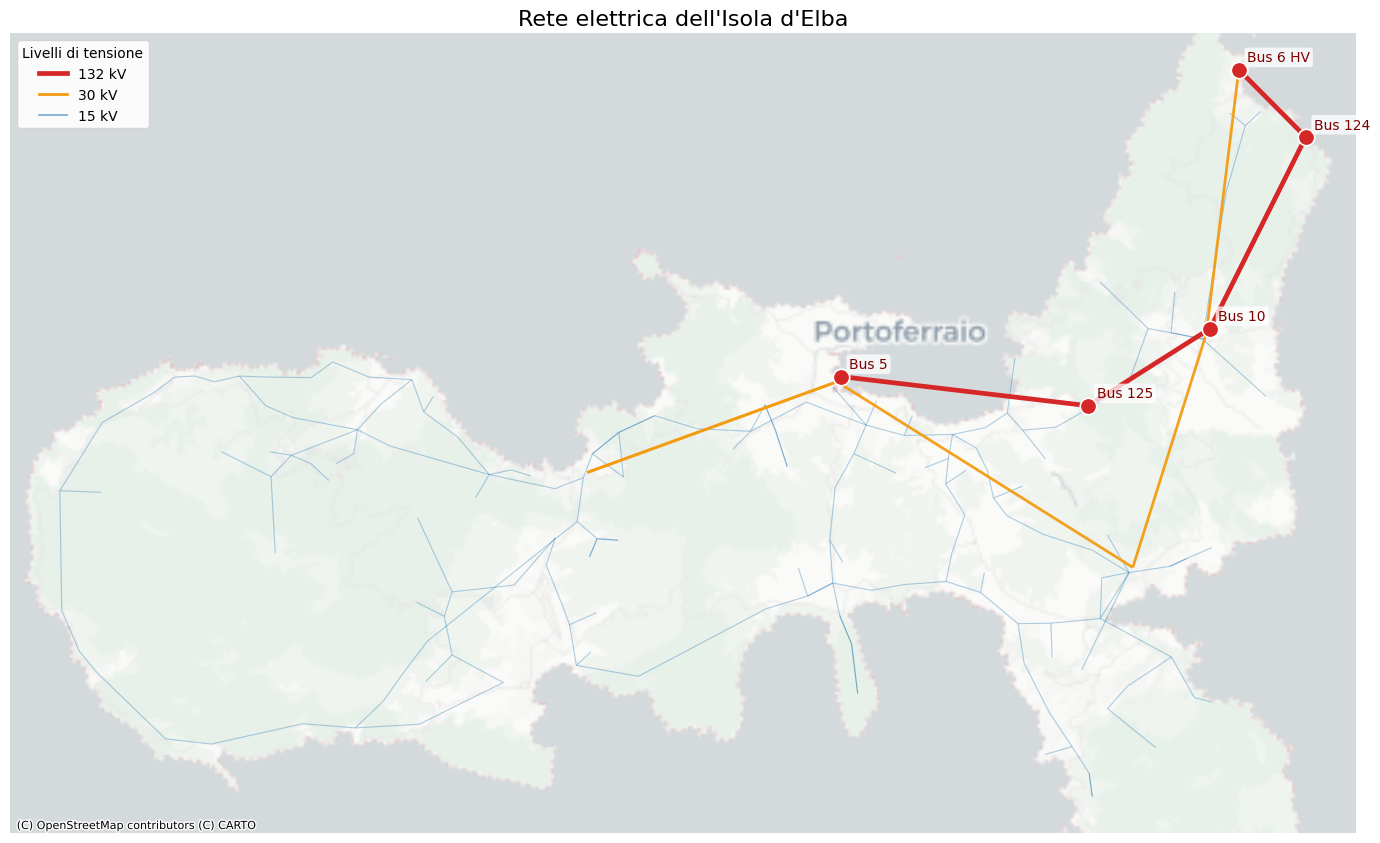

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Point
import contextily as ctx
from matplotlib.lines import Line2D

n = n_mod


# 0) Controllo rapido: assicurati di stare usando n_mod
#    dopo aver eseguito le celle 7-11

print("Numero linee totali:", len(n.lines))

for name in [
    "TIE_microgrid_1_bus_162_TO_microgrid_1_bus_18",
    "TIE_microgrid_1_bus_162_TO_microgrid_1_bus_76",
    "TIE_microgrid_1_bus_15_TO_microgrid_1_bus_98",
    "TIE_microgrid_1_bus_88_TO_microgrid_1_bus_147",
    "AT_microgrid_1_bus_124_TO_microgrid_1_bus_6_HV"
]:
    print(f"{name}: ", name in n.lines.index)
-
# 1) GeoDataFrame linee
#    v_nom ricavata dai BUS

line_records = []

for idx, row in n.lines.iterrows():
    bus0 = row["bus0"]
    bus1 = row["bus1"]

    x0 = float(n.buses.at[bus0, "x"])
    y0 = float(n.buses.at[bus0, "y"])
    x1 = float(n.buses.at[bus1, "x"])
    y1 = float(n.buses.at[bus1, "y"])

    v0 = float(n.buses.at[bus0, "v_nom"])
    v1 = float(n.buses.at[bus1, "v_nom"])

    # tensione della linea dedotta dai bus
    if np.isclose(v0, v1):
        line_v_nom = v0
    else:
        # caso raro: linea tra bus a tensione diversa
        # la teniamo comunque nel dataset
        line_v_nom = np.nan

    line_records.append({
        "name": idx,
        "bus0": bus0,
        "bus1": bus1,
        "v_bus0": v0,
        "v_bus1": v1,
        "v_nom_calc": line_v_nom,
        "geometry": LineString([(x0, y0), (x1, y1)])
    })

gdf_lines = gpd.GeoDataFrame(line_records, crs="EPSG:4326")


# 2) GeoDataFrame nodi

bus_records = []
for bus, row in n.buses.iterrows():
    bus_records.append({
        "bus": bus,
        "v_nom": float(row["v_nom"]),
        "geometry": Point(float(row["x"]), float(row["y"]))
    })

gdf_buses = gpd.GeoDataFrame(bus_records, crs="EPSG:4326")


# 3) Filtri tensione
#    usando v_nom_calc

gdf_132 = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 132.0)].copy()
gdf_30  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 30.0)].copy()
gdf_15  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 15.0)].copy()

# nodi delle linee 132 kV
buses_132 = sorted(set(gdf_132["bus0"]).union(set(gdf_132["bus1"])))
gdf_buses_132 = gdf_buses[gdf_buses["bus"].isin(buses_132)].copy()


# 4) Etichette corte

label_map = {
    "microgrid_1_bus_124": "Bus 124",
    "microgrid_1_bus_125": "Bus 125",
    "microgrid_1_bus_5":   "Bus 5",
    "microgrid_1_bus_10":  "Bus 10",
    "microgrid_1_bus_6_HV": "Bus 6 HV",
}

gdf_buses_132["label"] = gdf_buses_132["bus"].map(lambda x: label_map.get(x, x))

# 5) Proiezione Web Mercator

gdf_15_web = gdf_15.to_crs(epsg=3857)
gdf_30_web = gdf_30.to_crs(epsg=3857)
gdf_132_web = gdf_132.to_crs(epsg=3857)
gdf_buses_132_web = gdf_buses_132.to_crs(epsg=3857)
gdf_lines_web = gdf_lines.to_crs(epsg=3857)


# 6) Plot

fig, ax = plt.subplots(figsize=(14, 9))

# 15 kV
if not gdf_15_web.empty:
    gdf_15_web.plot(
        ax=ax,
        color="#1f77b4",
        linewidth=0.8,
        alpha=0.35,
        zorder=2
    )

# 30 kV
if not gdf_30_web.empty:
    gdf_30_web.plot(
        ax=ax,
        color="#f39c12",
        linewidth=2.0,
        alpha=0.95,
        zorder=3
    )

# 132 kV
if not gdf_132_web.empty:
    gdf_132_web.plot(
        ax=ax,
        color="#d62728",
        linewidth=3.4,
        alpha=1.0,
        zorder=4
    )

# nodi 132 kV
if not gdf_buses_132_web.empty:
    gdf_buses_132_web.plot(
        ax=ax,
        color="#d62728",
        edgecolor="white",
        linewidth=1.2,
        markersize=140,
        zorder=5
    )

# etichette nodi 132 kV
for _, row in gdf_buses_132_web.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.annotate(
        row["label"],
        xy=(x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        color="#7f0000",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
        zorder=6
    )


# 7) Extent

all_bounds = gdf_lines_web.total_bounds
xmin, ymin, xmax, ymax = all_bounds
dx = (xmax - xmin) * 0.04
dy = (ymax - ymin) * 0.05

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)


# 8) Basemap

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)


# 9) Legenda

legend_elements = [
    Line2D([0], [0], color="#d62728", lw=3.4, label="132 kV"),
    Line2D([0], [0], color="#f39c12", lw=2.0, label="30 kV"),
    Line2D([0], [0], color="#1f77b4", lw=1.2, alpha=0.6, label="15 kV"),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="lightgray",
    title="Livelli di tensione"
)

ax.set_title("Rete elettrica dell'Isola d'Elba", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("rete_elba_finale.png", dpi=300, bbox_inches="tight")
plt.show()

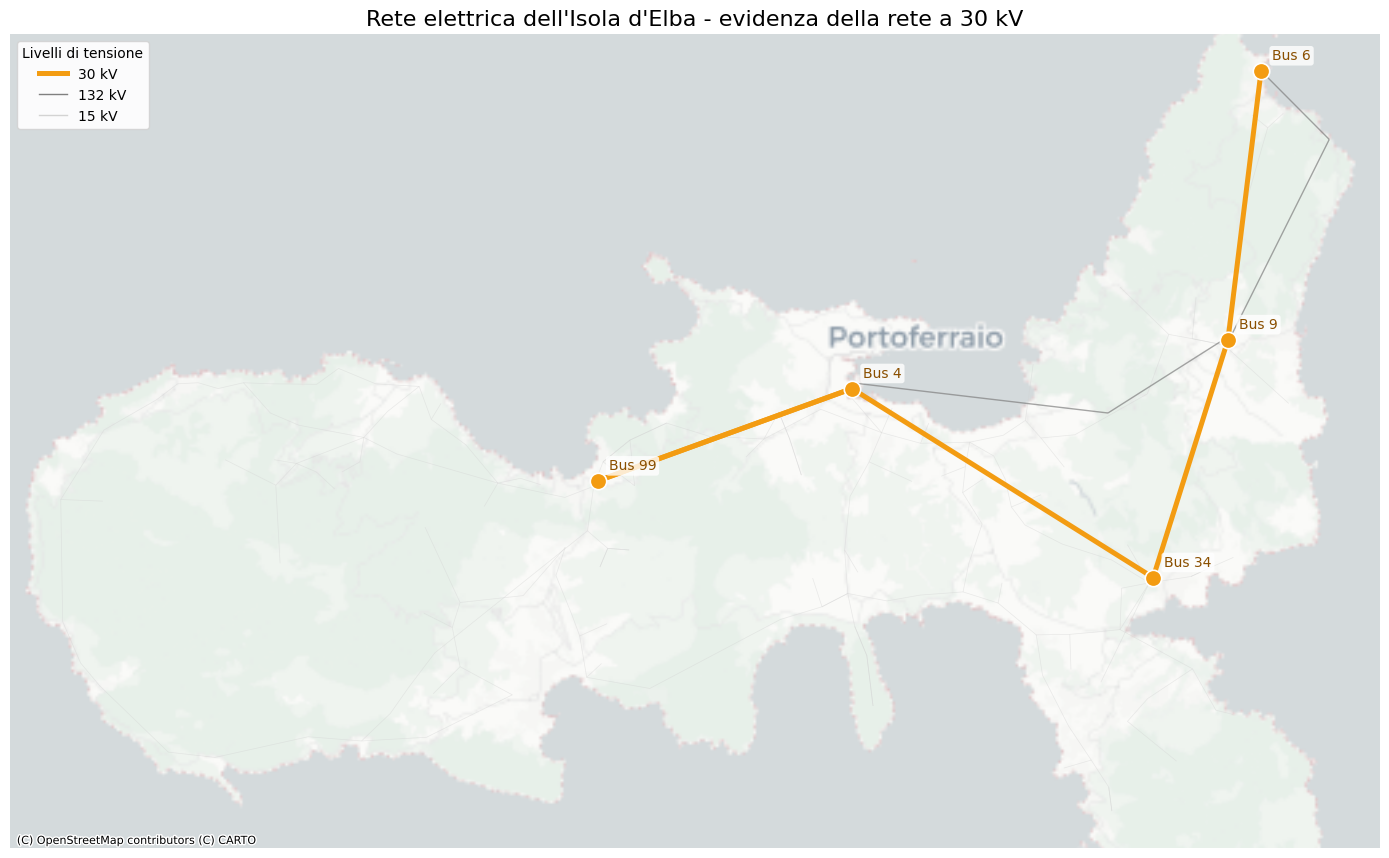

In [ ]:

n = n_mod


# 0) GeoDataFrame linee con tensione dedotta dai bus
line_records = []

for idx, row in n.lines.iterrows():
    bus0 = row["bus0"]
    bus1 = row["bus1"]

    x0 = float(n.buses.at[bus0, "x"])
    y0 = float(n.buses.at[bus0, "y"])
    x1 = float(n.buses.at[bus1, "x"])
    y1 = float(n.buses.at[bus1, "y"])

    v0 = float(n.buses.at[bus0, "v_nom"])
    v1 = float(n.buses.at[bus1, "v_nom"])

    if np.isclose(v0, v1):
        line_v_nom = v0
    else:
        line_v_nom = np.nan

    line_records.append({
        "name": idx,
        "bus0": bus0,
        "bus1": bus1,
        "v_bus0": v0,
        "v_bus1": v1,
        "v_nom_calc": line_v_nom,
        "geometry": LineString([(x0, y0), (x1, y1)])
    })

gdf_lines = gpd.GeoDataFrame(line_records, crs="EPSG:4326")


# 1) GeoDataFrame nodi
bus_records = []

for bus, row in n.buses.iterrows():
    bus_records.append({
        "bus": bus,
        "v_nom": float(row["v_nom"]),
        "geometry": Point(float(row["x"]), float(row["y"]))
    })

gdf_buses = gpd.GeoDataFrame(bus_records, crs="EPSG:4326")

# 2) Filtri per livello di tensione
gdf_132 = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 132.0)].copy()
gdf_30  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 30.0)].copy()
gdf_15  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 15.0)].copy()

# nodi appartenenti alla rete 30 kV
buses_30 = sorted(set(gdf_30["bus0"]).union(set(gdf_30["bus1"])))
gdf_buses_30 = gdf_buses[gdf_buses["bus"].isin(buses_30)].copy()


# 3) Etichette nodi 30 kV
def short_label(bus_name):
    return bus_name.replace("microgrid_1_bus_", "Bus ")

gdf_buses_30["label"] = gdf_buses_30["bus"].apply(short_label)

# 4) Proiezione Web Mercator
gdf_15_web = gdf_15.to_crs(epsg=3857)
gdf_30_web = gdf_30.to_crs(epsg=3857)
gdf_132_web = gdf_132.to_crs(epsg=3857)
gdf_buses_30_web = gdf_buses_30.to_crs(epsg=3857)
gdf_lines_web = gdf_lines.to_crs(epsg=3857)

# 5) Plot

fig, ax = plt.subplots(figsize=(14, 9))

# 15 kV: visibili ma sottili
if not gdf_15_web.empty:
    gdf_15_web.plot(
        ax=ax,
        color="lightgray",
        linewidth=0.5,
        alpha=0.45,
        zorder=2
    )

# 132 kV: visibili ma sottili
if not gdf_132_web.empty:
    gdf_132_web.plot(
        ax=ax,
        color="gray",
        linewidth=1.0,
        alpha=0.7,
        zorder=3
    )

# 30 kV: ben evidenziate
if not gdf_30_web.empty:
    gdf_30_web.plot(
        ax=ax,
        color="#f39c12",
        linewidth=3.6,
        alpha=1.0,
        zorder=4
    )

# nodi 30 kV
if not gdf_buses_30_web.empty:
    gdf_buses_30_web.plot(
        ax=ax,
        color="#f39c12",
        edgecolor="white",
        linewidth=1.2,
        markersize=140,
        zorder=5
    )

# etichette nodi 30 kV con offset
for _, row in gdf_buses_30_web.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.annotate(
        row["label"],
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        color="#8a4f00",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.80
        ),
        zorder=6
    )


# 6) Extent
all_bounds = gdf_lines_web.total_bounds
xmin, ymin, xmax, ymax = all_bounds
dx = (xmax - xmin) * 0.04
dy = (ymax - ymin) * 0.05

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)


# 7) Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

# 8) Legenda
legend_elements = [
    Line2D([0], [0], color="#f39c12", lw=3.6, label="30 kV"),
    Line2D([0], [0], color="gray", lw=1.0, label="132 kV"),
    Line2D([0], [0], color="lightgray", lw=1.0, label="15 kV"),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="lightgray",
    title="Livelli di tensione"
)

ax.set_title("Rete elettrica dell'Isola d'Elba - evidenza della rete a 30 kV", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("rete_elba_30kV_evidenziata.png", dpi=300, bbox_inches="tight")
plt.show()

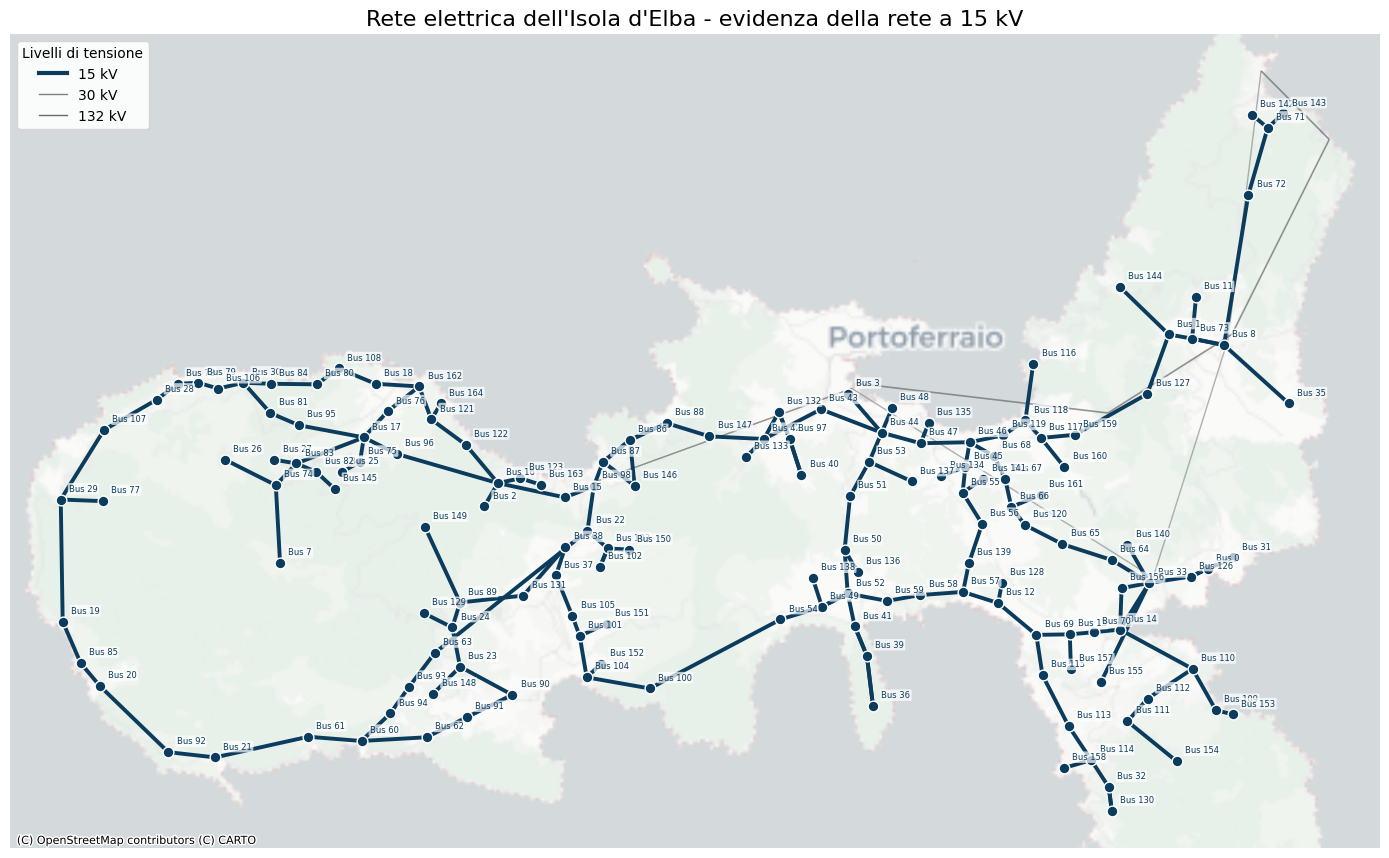

In [ ]:

n = n_mod

# 0) GeoDataFrame linee con tensione dai bus

line_records = []

for idx, row in n.lines.iterrows():
    bus0 = row["bus0"]
    bus1 = row["bus1"]

    x0 = float(n.buses.at[bus0, "x"])
    y0 = float(n.buses.at[bus0, "y"])
    x1 = float(n.buses.at[bus1, "x"])
    y1 = float(n.buses.at[bus1, "y"])

    v0 = float(n.buses.at[bus0, "v_nom"])
    v1 = float(n.buses.at[bus1, "v_nom"])

    if np.isclose(v0, v1):
        line_v_nom = v0
    else:
        line_v_nom = np.nan

    line_records.append({
        "name": idx,
        "bus0": bus0,
        "bus1": bus1,
        "v_nom_calc": line_v_nom,
        "geometry": LineString([(x0, y0), (x1, y1)])
    })

gdf_lines = gpd.GeoDataFrame(line_records, crs="EPSG:4326")

# 1) GeoDataFrame nodi

bus_records = []

for bus, row in n.buses.iterrows():
    bus_records.append({
        "bus": bus,
        "v_nom": float(row["v_nom"]),
        "geometry": Point(float(row["x"]), float(row["y"]))
    })

gdf_buses = gpd.GeoDataFrame(bus_records, crs="EPSG:4326")

# 2) Filtri tensione

gdf_132 = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 132.0)].copy()
gdf_30  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 30.0)].copy()
gdf_15  = gdf_lines[np.isclose(gdf_lines["v_nom_calc"], 15.0)].copy()

# nodi rete 15 kV
buses_15 = sorted(set(gdf_15["bus0"]).union(set(gdf_15["bus1"])))
gdf_buses_15 = gdf_buses[gdf_buses["bus"].isin(buses_15)].copy()


# 3) Etichette nodi 15 kV

def short_label(bus_name):
    return bus_name.replace("microgrid_1_bus_", "Bus ")

gdf_buses_15["label"] = gdf_buses_15["bus"].apply(short_label)


# 4) Proiezione

gdf_15_web = gdf_15.to_crs(epsg=3857)
gdf_30_web = gdf_30.to_crs(epsg=3857)
gdf_132_web = gdf_132.to_crs(epsg=3857)
gdf_buses_15_web = gdf_buses_15.to_crs(epsg=3857)
gdf_lines_web = gdf_lines.to_crs(epsg=3857)

# 5) Plot

fig, ax = plt.subplots(figsize=(14, 9))

# 30 kV (sottile)
if not gdf_30_web.empty:
    gdf_30_web.plot(
        ax=ax,
        color="gray",
        linewidth=1.0,
        alpha=0.6,
        zorder=2
    )

# 132 kV (sottile)
if not gdf_132_web.empty:
    gdf_132_web.plot(
        ax=ax,
        color="dimgray",
        linewidth=1.2,
        alpha=0.7,
        zorder=3
    )

# 15 kV (EVIDENZIATA)
if not gdf_15_web.empty:
    gdf_15_web.plot(
        ax=ax,
        color="#0b3c5d",   # blu scuro
        linewidth=2.8,
        alpha=1.0,
        zorder=4
    )

# nodi 15 kV
if not gdf_buses_15_web.empty:
    gdf_buses_15_web.plot(
        ax=ax,
        color="#0b3c5d",
        edgecolor="white",
        linewidth=1.0,
        markersize=60,
        zorder=5
    )

# etichette (opzionali - puoi commentarle se troppo dense)
for _, row in gdf_buses_15_web.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.annotate(
        row["label"],
        xy=(x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=6,
        color="#0b3c5d",
        bbox=dict(
            boxstyle="round,pad=0.15",
            fc="white",
            ec="none",
            alpha=0.7
        ),
        zorder=6
    )


# 6) Extent
xmin, ymin, xmax, ymax = gdf_lines_web.total_bounds
dx = (xmax - xmin) * 0.04
dy = (ymax - ymin) * 0.05

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)


# 7) Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)


# 8) Legenda
legend_elements = [
    Line2D([0], [0], color="#0b3c5d", lw=3, label="15 kV"),
    Line2D([0], [0], color="gray", lw=1, label="30 kV"),
    Line2D([0], [0], color="dimgray", lw=1, label="132 kV"),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="lightgray",
    title="Livelli di tensione"
)

ax.set_title("Rete elettrica dell'Isola d'Elba - evidenza della rete a 15 kV", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("rete_elba_15kV_evidenziata.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Linea Completa 132 / 30 / 15 kV
def short_label(bus_name):
    return bus_name.replace("microgrid_1_bus_", "Bus ")

gdf_buses["label"] = gdf_buses["bus"].apply(short_label)

gdf_buses_132 = gdf_buses[np.isclose(gdf_buses["v_nom"], 132.0)].copy()
gdf_buses_30  = gdf_buses[np.isclose(gdf_buses["v_nom"], 30.0)].copy()
gdf_buses_15  = gdf_buses[np.isclose(gdf_buses["v_nom"], 15.0)].copy()

# Nodo slack
gdf_slack = gdf_buses[gdf_buses["label"] == "Bus 124"].copy()


# 4) Proiezione
gdf_132_web = gdf_132.to_crs(epsg=3857)
gdf_30_web  = gdf_30.to_crs(epsg=3857)
gdf_15_web  = gdf_15.to_crs(epsg=3857)

gdf_buses_132_web = gdf_buses_132.to_crs(epsg=3857)
gdf_buses_30_web  = gdf_buses_30.to_crs(epsg=3857)
gdf_buses_15_web  = gdf_buses_15.to_crs(epsg=3857)

gdf_slack_web = gdf_slack.to_crs(epsg=3857)
gdf_lines_web = gdf_lines.to_crs(epsg=3857)


# 5) Plot completo 132 / 30 / 15 kV
fig, ax = plt.subplots(figsize=(16, 10))

# Linee 15 kV
if not gdf_15_web.empty:
    gdf_15_web.plot(
        ax=ax,
        color="#0b3c5d",
        linewidth=1.7,
        alpha=0.9,
        zorder=3
    )

# Linee 30 kV
if not gdf_30_web.empty:
    gdf_30_web.plot(
        ax=ax,
        color="#f39c12",
        linewidth=2.6,
        alpha=1.0,
        zorder=4
    )

# Linee 132 kV
if not gdf_132_web.empty:
    gdf_132_web.plot(
        ax=ax,
        color="#d62728",
        linewidth=3.2,
        alpha=1.0,
        zorder=5
    )

# Nodi 15 kV
if not gdf_buses_15_web.empty:
    gdf_buses_15_web.plot(
        ax=ax,
        color="#0b3c5d",
        edgecolor="white",
        linewidth=0.7,
        markersize=35,
        zorder=6
    )

# Nodi 30 kV
if not gdf_buses_30_web.empty:
    gdf_buses_30_web.plot(
        ax=ax,
        color="#f39c12",
        edgecolor="white",
        linewidth=1.0,
        markersize=75,
        zorder=7
    )

# Nodi 132 kV
if not gdf_buses_132_web.empty:
    gdf_buses_132_web.plot(
        ax=ax,
        color="#d62728",
        edgecolor="white",
        linewidth=1.0,
        markersize=95,
        zorder=8
    )


# 6) Evidenziazione nodo slack - Bus 124
if not gdf_slack_web.empty:
    # Cerchio esterno viola
    gdf_slack_web.plot(
        ax=ax,
        facecolor="none",
        edgecolor="purple",
        linewidth=2.8,
        markersize=420,
        zorder=12
    )

    # Nodo slack evidenziato in viola
    gdf_slack_web.plot(
        ax=ax,
        color="purple",
        edgecolor="white",
        linewidth=1.2,
        markersize=110,
        zorder=13
    )

    # Etichetta dedicata
    for _, row in gdf_slack_web.iterrows():
        ax.annotate(
            "Slack bus\nBus 124",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(14, 14),
            textcoords="offset points",
            fontsize=9,
            color="purple",
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="purple",
                alpha=0.9
            ),
            zorder=14
        )

# 7) Etichette nodi
def add_labels(gdf, color, fontsize, dx=6, dy=6):
    for _, row in gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        ax.annotate(
            row["label"],
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=fontsize,
            color=color,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.15",
                fc="white",
                ec="none",
                alpha=0.75
            ),
            zorder=10
        )

add_labels(gdf_buses_132_web, "#d62728", 8)
add_labels(gdf_buses_30_web, "#f39c12", 8)
add_labels(gdf_buses_15_web, "#0b3c5d", 5)


# 8) Extent
xmin, ymin, xmax, ymax = gdf_lines_web.total_bounds
dx = (xmax - xmin) * 0.04
dy = (ymax - ymin) * 0.05

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

# 9) Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

# 10) Legenda
legend_elements = [
    Line2D([0], [0], color="#d62728", lw=3.2, label="132 kV"),
    Line2D([0], [0], color="#f39c12", lw=2.6, label="30 kV"),
    Line2D([0], [0], color="#0b3c5d", lw=1.7, label="15 kV"),
    Line2D(
        [0], [0],
        marker="o",
        color="purple",
        markerfacecolor="none",
        markeredgecolor="purple",
        markersize=11,
        lw=0,
        label="Nodo slack - Bus 124"
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="lightgray",
    title="Livelli di tensione"
)

ax.set_title(
    "Rete elettrica dell'Isola d'Elba - livelli di tensione e nodo slack",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    "rete_elba_livelli_tensione_con_slack_bus_124.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

RICOSTRUZIONE CARICO ELETTRICO

In [ ]:
import numpy as np
import pandas as pd

gse_path = "profili GSE_prelievo_2025.xlsx"

# Scelte energia mensile (GWh) -> energia media giornaliera (MWh/giorno)
JUL_GWH = 19.0
DEC_GWH = 11.0

# Giorni del mese
DAYS_IN_MONTH = 31

E_JUL_MWH_DAY = (JUL_GWH * 1000) / DAYS_IN_MONTH
E_DEC_MWH_DAY = (DEC_GWH * 1000) / DAYS_IN_MONTH

SCENARIOS = {
    "2025-07-19": {"weights": {"PAUM": 0.60, "PDMM": 0.40}, "e_day_mwh": E_JUL_MWH_DAY},
    "2025-12-25": {"weights": {"PDMM": 0.55, "PAUM": 0.45}, "e_day_mwh": E_DEC_MWH_DAY},
}

HOURS = ["00:00:00", "12:00:00", "19:00:00"]

# 1) LETTURA EXCEL GSE

gse = pd.read_excel(gse_path, sheet_name=0)

dt_col = None
for c in gse.columns:
    if str(c).strip().lower() in ["data ora", "data_ora", "dataora", "datetime", "timestamp"]:
        dt_col = c
        break

if dt_col is None:
    raise ValueError("Non trovo la colonna datetime nel file Excel (es. 'Data ora').")

gse[dt_col] = pd.to_datetime(gse[dt_col])

gse = gse.sort_values(dt_col).set_index(dt_col)
gse.index = gse.index.round("h")
gse = gse.groupby(gse.index).mean()

needed = set()
for cfg in SCENARIOS.values():
    needed |= set(cfg["weights"].keys())

missing = [c for c in needed if c not in gse.columns]
if missing:
    raise ValueError(f"Mancano nel file Excel le colonne profilo: {missing}")

# 2) FUNZIONE PROFILO GIORNALIERO SCALATO SU ENERGIA


def composite_day_mw_energy(day_str: str, weights: dict, e_day_mwh: float) -> pd.Series:
    day = pd.Timestamp(day_str).date()
    day_df = gse[gse.index.date == day]

    if len(day_df) != 24:
        raise ValueError(
            f"Per {day_str} attese 24 ore, trovate {len(day_df)}. "
            f"Controlla che il file abbia dati orari completi per quel giorno."
        )

    s = pd.Series(0.0, index=day_df.index)
    for prof, w_ in weights.items():
        s = s + float(w_) * day_df[prof].astype(float)

    if float(s.sum()) == 0.0:
        raise ValueError(f"Somma profili nulla per {day_str}: non posso normalizzare.")

    frac = s / s.sum()
    p_mw = frac * float(e_day_mwh)

    return p_mw


# 3) COSTRUZIONE 6 SNAPSHOT

snapshots_list = []
snap_p_list = []

print("=== PARAMETRI ENERGETICI ===")
print(f"Luglio: {JUL_GWH} GWh/mese -> {E_JUL_MWH_DAY:.2f} MWh/giorno -> P_avg attesa ~ {E_JUL_MWH_DAY/24:.2f} MW")
print(f"Dic.:   {DEC_GWH} GWh/mese -> {E_DEC_MWH_DAY:.2f} MWh/giorno -> P_avg attesa ~ {E_DEC_MWH_DAY/24:.2f} MW")

for day_str, cfg in SCENARIOS.items():
    s_mw = composite_day_mw_energy(day_str, cfg["weights"], cfg["e_day_mwh"])

    e_obt_mwh = float(s_mw.sum())
    p_avg = float(s_mw.mean())
    p_peak = float(s_mw.max())
    peak_time = s_mw.idxmax()

    print(f"\n=== {day_str} ===")
    print(f"E_day target  : {cfg['e_day_mwh']:.2f} MWh")
    print(f"E_day ottenuta: {e_obt_mwh:.2f} MWh")
    print(f"P_avg         : {p_avg:.2f} MW")
    print(f"P_peak        : {p_peak:.2f} MW (alle {peak_time.time()})")

    for hh in HOURS:
        ts = pd.Timestamp(f"{day_str} {hh}")
        if ts not in s_mw.index:
            raise ValueError(f"Timestamp {ts} non presente nella serie oraria del giorno {day_str}.")
        p_ts = float(s_mw.loc[ts])
        snapshots_list.append(ts)
        snap_p_list.append(p_ts)
        print(f"P({hh})       : {p_ts:.2f} MW")

snapshots = pd.DatetimeIndex(snapshots_list)
snap_p_mw = pd.Series(snap_p_list, index=snapshots, name="TotalLoad_MW")


# 4) PESI SPAZIALI BASE


base = None

# 1) provo con loads.p_set
if "p_set" in n_mod.loads.columns:
    s = pd.to_numeric(n_mod.loads["p_set"], errors="coerce").fillna(0.0).clip(lower=0.0)
    if float(s.sum()) > 0:
        base = s.copy()
        print("Pesi base presi da n_mod.loads.p_set")

# 2) provo con loads.p_nom
if base is None and "p_nom" in n_mod.loads.columns:
    s = pd.to_numeric(n_mod.loads["p_nom"], errors="coerce").fillna(0.0).clip(lower=0.0)
    if float(s.sum()) > 0:
        base = s.copy()
        print("Pesi base presi da n_mod.loads.p_nom")

# 3) provo con la media temporale di loads_t.p_set
if base is None and hasattr(n_mod, "loads_t") and hasattr(n_mod.loads_t, "p_set"):
    if n_mod.loads_t.p_set is not None and not n_mod.loads_t.p_set.empty:
        s = n_mod.loads_t.p_set.apply(pd.to_numeric, errors="coerce").mean(axis=0).fillna(0.0).clip(lower=0.0)
        s = s.reindex(n_mod.loads.index).fillna(0.0)
        if float(s.sum()) > 0:
            base = s.copy()
            print("Pesi base presi da media di n_mod.loads_t.p_set")

# 4) fallback: uniforme sui load
if base is None:
    if len(n_mod.loads.index) == 0:
        raise ValueError("La rete non contiene load in n_mod.loads.")
    base = pd.Series(1.0, index=n_mod.loads.index, dtype=float)
    print("Attenzione: pesi base uniformi sui load (fallback)")

base = base.reindex(n_mod.loads.index).fillna(0.0).clip(lower=0.0)

print("Numero load:", len(base))
print("Somma base:", float(base.sum()))


# 5) CORREZIONE ZONA PORTOFERRAIO


portoferraio_buses = ["microgrid_1_bus_3", "microgrid_1_bus_4"]
mask_pf = n_mod.loads.bus.isin(portoferraio_buses)

if mask_pf.sum() == 0:
    raise ValueError(
        "Non trovo load attestati sui bus di Portoferraio (3 e 4). "
        "Controlla n_mod.loads[['bus']]."
    )

target_pf = 11.6 / 43.2

total_base = float(base.sum())
current_pf = float(base.loc[mask_pf].sum()) / total_base

print("\n=== CORREZIONE SPAZIALE PORTOFERRAIO ===")
print(f"Quota attuale Portoferraio = {current_pf:.4f}")
print(f"Quota target  Portoferraio = {target_pf:.4f}")

if current_pf <= 0:
    raise ValueError(
        "La quota base di Portoferraio è nulla. "
        "Probabilmente i load della zona non sono sui bus 3 e 4."
    )

if current_pf >= 1:
    raise ValueError("Tutti i carichi risultano in Portoferraio: controlla la rete.")

factor_pf = target_pf / current_pf
factor_other_pf = (1.0 - target_pf) / (1.0 - current_pf)

base_corr = base.copy()
base_corr.loc[mask_pf] *= factor_pf
base_corr.loc[~mask_pf] *= factor_other_pf

print(f"Fattore scala Portoferraio = {factor_pf:.4f}")
print(f"Fattore scala altri        = {factor_other_pf:.4f}")


# 6) CORREZIONE LOCALE RAMO OVEST CRITICO


critical_buses = [
    "microgrid_1_bus_77",
    "microgrid_1_bus_29",
    "microgrid_1_bus_19",
    "microgrid_1_bus_85",
    "microgrid_1_bus_20",
    "microgrid_1_bus_107",
]

mask_critical = n_mod.loads.bus.isin(critical_buses)

print("\n=== CORREZIONE LOCALE RAMO OVEST ===")
print("Numero load su ramo critico:", int(mask_critical.sum()))

critical_factor = 0.95

base_corr2 = base_corr.copy()
base_corr2.loc[mask_critical] *= critical_factor

# normalizzazione finale
w = base_corr2 / base_corr2.sum()

print(f"Fattore locale ramo critico = {critical_factor:.4f}")
print(f"Quota finale Portoferraio   = {float(w.loc[mask_pf].sum()):.4f}")
print(f"Quota finale ramo critico   = {float(w.loc[mask_critical].sum()):.4f}")
print(f"Somma pesi                  = {float(w.sum()):.4f}")


# 7) MATRICE NODALE (snapshot x load)


p_mat = pd.DataFrame(
    data=np.outer(snap_p_mw.values, w.values),
    index=snap_p_mw.index,
    columns=n_mod.loads.index
)

# 8) ASSEGNAZIONE ALLA RETE MODIFICATA


n_mod.set_snapshots(p_mat.index)

n_mod.loads_t.p_set = pd.DataFrame(0.0, index=n_mod.snapshots, columns=n_mod.loads.index)
n_mod.loads_t.p_set.loc[:, :] = p_mat.astype(float)


# 9) CHECK FINALE


check = pd.DataFrame({
    "Target_MW": p_mat.sum(axis=1),
    "Somma_Loads_MW": n_mod.loads_t.p_set.sum(axis=1),
    "NaN_count": n_mod.loads_t.p_set.isna().sum(axis=1)
})

print("\n=== CHECK ASSEGNAZIONE ===")
print(check)

print("\nGenerazione disponibile (somma p_nom):", float(n_mod.generators.p_nom.sum()))
print("Carico massimo (tra gli snapshot):", float(n_mod.loads_t.p_set.sum(axis=1).max()))
print("Numero snapshot impostati:", len(n_mod.snapshots))
print("Snapshot:", list(n_mod.snapshots))

=== PARAMETRI ENERGETICI ===
Luglio: 19.0 GWh/mese -> 612.90 MWh/giorno -> P_avg attesa ~ 25.54 MW
Dic.:   11.0 GWh/mese -> 354.84 MWh/giorno -> P_avg attesa ~ 14.78 MW

=== 2025-07-19 ===
E_day target  : 612.90 MWh
E_day ottenuta: 612.90 MWh
P_avg         : 25.54 MW
P_peak        : 31.74 MW (alle 18:00:00)
P(00:00:00)       : 20.91 MW
P(12:00:00)       : 30.75 MW
P(19:00:00)       : 30.97 MW

=== 2025-12-25 ===
E_day target  : 354.84 MWh
E_day ottenuta: 354.84 MWh
P_avg         : 14.78 MW
P_peak        : 20.29 MW (alle 18:00:00)
P(00:00:00)       : 10.57 MW
P(12:00:00)       : 17.73 MW
P(19:00:00)       : 19.76 MW
Attenzione: pesi base uniformi sui load (fallback)
Numero load: 161
Somma base: 161.0

=== CORREZIONE SPAZIALE PORTOFERRAIO ===
Quota attuale Portoferraio = 0.0124
Quota target  Portoferraio = 0.2685
Fattore scala Portoferraio = 21.6157
Fattore scala altri        = 0.7407

=== CORREZIONE LOCALE RAMO OVEST ===
Numero load su ramo critico: 6
Fattore locale ramo critico = 0.950

INSTALLAZIONE GENERAZIONE DISTRIBUITA, TUTTI I NODI PQ, NODO 124 SLACK 

In [ ]:
# Un solo punto di scambio esterno
# Slack bus = 124
# bus 5 e 6 restano nodi interni

slack_name = "grid_import_microgrid_1_bus_124"
slack_bus  = "microgrid_1_bus_124"

# controllo che il generatore slack esista
if slack_name not in n_mod.generators.index:
    raise ValueError(f"Generatore slack {slack_name} non presente in n_mod.generators")

if slack_bus not in n_mod.buses.index:
    raise ValueError(f"Bus slack {slack_bus} non presente in n_mod.buses")

# inizializzo colonne se mancanti
for col, default in {
    "p_min_pu": 0.0,
    "p_max_pu": 1.0,
    "v_mag_pu_set": np.nan,
    "q_min": np.nan,
    "q_max": np.nan,
}.items():
    if col not in n_mod.generators.columns:
        n_mod.generators[col] = default

# insiemi generatori
solar_gens = n_mod.generators.index[n_mod.generators.carrier == "solar"]
wind_gens  = n_mod.generators.index[n_mod.generators.carrier == "onwind"]
res_gens   = n_mod.generators.index[n_mod.generators.carrier.isin(["solar", "onwind"])]
grid_gens  = n_mod.generators.index[n_mod.generators.carrier == "grid_import"]

# potenze nominali RES
PV_P_NOM_TOTAL   = 8.0
WIND_P_NOM_TOTAL = 0.0

if len(solar_gens) > 0:
    n_mod.generators.loc[solar_gens, "p_nom"] = PV_P_NOM_TOTAL / len(solar_gens)

if len(wind_gens) > 0:
    n_mod.generators.loc[wind_gens, "p_nom"] = WIND_P_NOM_TOTAL / len(wind_gens)

# imposto tutti i grid_import come non-slack (PQ)
if len(grid_gens) > 0:
    n_mod.generators.loc[grid_gens, "control"] = "PQ"
    n_mod.generators.loc[grid_gens, "v_mag_pu_set"] = np.nan

# opzionale: si puo lasciare gli altri grid_import con p_nom=0
other_grid_gens = [g for g in grid_gens if g != slack_name]
if len(other_grid_gens) > 0:
    n_mod.generators.loc[other_grid_gens, "p_nom"] = 0.0
    n_mod.generators.loc[other_grid_gens, "p_min_pu"] = 0.0
    n_mod.generators.loc[other_grid_gens, "p_max_pu"] = 0.0
    n_mod.generators.loc[other_grid_gens, "q_min"] = 0.0
    n_mod.generators.loc[other_grid_gens, "q_max"] = 0.0

# imposto l'unico slack
n_mod.generators.loc[slack_name, "bus"] = slack_bus
n_mod.generators.loc[slack_name, "carrier"] = "grid_import"
n_mod.generators.loc[slack_name, "p_nom"] = 1e3
n_mod.generators.loc[slack_name, "p_min_pu"] = -1.0
n_mod.generators.loc[slack_name, "p_max_pu"] =  1.0
n_mod.generators.loc[slack_name, "control"] = "Slack"
n_mod.generators.loc[slack_name, "v_mag_pu_set"] = 1.0
n_mod.generators.loc[slack_name, "q_min"] = -1e3
n_mod.generators.loc[slack_name, "q_max"] =  1e3

# limiti reattivi RES
Q_CAP_FRAC_RES = 0.30
if len(res_gens) > 0:
    n_mod.generators.loc[res_gens, "q_min"] = -Q_CAP_FRAC_RES * n_mod.generators.loc[res_gens, "p_nom"]
    n_mod.generators.loc[res_gens, "q_max"] =  Q_CAP_FRAC_RES * n_mod.generators.loc[res_gens, "p_nom"]

# ricostruisco grid_gens dopo le modifiche
grid_gens = n_mod.generators.index[n_mod.generators.carrier == "grid_import"]

print("=== CHECK GENERATORI ===")
print("PV totale [MW]:", float(n_mod.generators.loc[solar_gens, "p_nom"].sum()) if len(solar_gens) > 0 else 0.0)
print("Wind totale [MW]:", float(n_mod.generators.loc[wind_gens, "p_nom"].sum()) if len(wind_gens) > 0 else 0.0)
print()
print(n_mod.generators.loc[
    grid_gens,
    ["bus", "carrier", "control", "v_mag_pu_set", "p_nom", "p_min_pu", "p_max_pu", "q_min", "q_max"]
])

print("\nSlack attivo:")
print(n_mod.generators.loc[
    [slack_name],
    ["bus", "carrier", "control", "v_mag_pu_set", "p_nom", "p_min_pu", "p_max_pu", "q_min", "q_max"]])

=== CHECK GENERATORI ===
PV totale [MW]: 8.0
Wind totale [MW]: 0.0

                                                 bus      carrier control  \
Generator                                                                   
grid_import_microgrid_1_bus_5      microgrid_1_bus_5  grid_import      PQ   
grid_import_microgrid_1_bus_6      microgrid_1_bus_6  grid_import      PQ   
grid_import_microgrid_1_bus_124  microgrid_1_bus_124  grid_import   Slack   

                                 v_mag_pu_set   p_nom  p_min_pu  p_max_pu  \
Generator                                                                   
grid_import_microgrid_1_bus_5             NaN     0.0       0.0       0.0   
grid_import_microgrid_1_bus_6             NaN     0.0       0.0       0.0   
grid_import_microgrid_1_bus_124           1.0  1000.0      -1.0       1.0   

                                  q_min   q_max  
Generator                                        
grid_import_microgrid_1_bus_5       0.0     0.0  
grid_impor

In [ ]:

# Capacity factor

pv_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.00,
    pd.Timestamp("2025-07-19 12:00:00"): 0.71,
    pd.Timestamp("2025-07-19 19:00:00"): 0.16,
    pd.Timestamp("2025-12-25 00:00:00"): 0.00,
    pd.Timestamp("2025-12-25 12:00:00"): 0.50,
    pd.Timestamp("2025-12-25 19:00:00"): 0.00,
}).reindex(n_mod.snapshots).fillna(0.0)

wind_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.12,
    pd.Timestamp("2025-07-19 12:00:00"): 0.12,
    pd.Timestamp("2025-07-19 19:00:00"): 0.14,
    pd.Timestamp("2025-12-25 00:00:00"): 0.18,
    pd.Timestamp("2025-12-25 12:00:00"): 0.18,
    pd.Timestamp("2025-12-25 19:00:00"): 0.19,
}).reindex(n_mod.snapshots).fillna(0.0)

# generatori

slack_name = "grid_import_microgrid_1_bus_124"

solar_gens = n_mod.generators.index[n_mod.generators.carrier == "solar"]
wind_gens  = n_mod.generators.index[n_mod.generators.carrier == "onwind"]

# p_max_pu

n_mod.generators_t.p_max_pu = pd.DataFrame(
    1.0, index=n_mod.snapshots, columns=n_mod.generators.index
)

for g in solar_gens:
    n_mod.generators_t.p_max_pu.loc[:, g] = pv_cf.values

for g in wind_gens:
    n_mod.generators_t.p_max_pu.loc[:, g] = wind_cf.values

n_mod.generators_t.p_max_pu.loc[:, slack_name] = 1.0

# p_set

n_mod.generators_t.p_set = pd.DataFrame(
    0.0, index=n_mod.snapshots, columns=n_mod.generators.index
)

for g in solar_gens:
    n_mod.generators_t.p_set.loc[:, g] = (
        float(n_mod.generators.at[g, "p_nom"]) * pv_cf.values
    )

for g in wind_gens:
    n_mod.generators_t.p_set.loc[:, g] = (
        float(n_mod.generators.at[g, "p_nom"]) * wind_cf.values
    )

n_mod.generators_t.p_set.loc[:, slack_name] = 0.0

# carichi → Q

COSPHI_LOAD = 0.98
tanphi_load = np.tan(np.arccos(COSPHI_LOAD))
n_mod.loads_t.q_set = n_mod.loads_t.p_set * tanphi_load


# Q generatori


n_mod.generators_t.q_set = pd.DataFrame(
    0.0, index=n_mod.snapshots, columns=n_mod.generators.index
)

dispatch_rows = []

for sns in n_mod.snapshots:

    p_load = float(n_mod.loads_t.p_set.loc[sns].sum())
    q_load = float(n_mod.loads_t.q_set.loc[sns].sum())

    p_res = float(n_mod.generators_t.p_set.loc[sns, solar_gens].sum())

    # PV NON fornisce reattivo
    q_res = 0.0

    # tutto il Q lo prende lo slack
    n_mod.generators_t.q_set.loc[sns, slack_name] = 0.0

    dispatch_rows.append({
        "snapshot": sns,
        "P_load_MW": p_load,
        "Q_load_MVAr": q_load,
        "P_RES_MW": p_res,
        "Q_RES_MVAr": q_res,
        "P_residual_MW": p_load - p_res,
        "Q_residual_MVAr": q_load,
        "system_mode": "IMPORT" if (p_load - p_res) > 1e-6 else "EXPORT"
    })

dispatch_df = pd.DataFrame(dispatch_rows).set_index("snapshot")

print("=== PIANO DI BILANCIO ===")
print(dispatch_df)


# POWER FLOW

pf_rows = []

for sns in n_mod.snapshots:

    print("\nSnapshot:", sns)

    n_mod.lpf(snapshots=[sns])
    res = n_mod.pf(snapshots=[sns], use_seed=True)

    conv = bool(res["converged"].loc[sns].any())

    row = {
        "snapshot": sns,
        "converged": conv,
        "P_slack_MW": float(n_mod.generators_t.p.loc[sns, slack_name]),
        "Q_slack_MVAr": float(n_mod.generators_t.q.loc[sns, slack_name]),
    }

    if conv:
        v = n_mod.buses_t.v_mag_pu.loc[sns]
        row["Vmin"] = float(v.min())
        row["Vmax"] = float(v.max())

    pf_rows.append(row)

df_pf = pd.DataFrame(pf_rows).set_index("snapshot")

print("\n=== RISULTATI PF ===")
print(df_pf)

=== PIANO DI BILANCIO ===
                     P_load_MW  Q_load_MVAr  P_RES_MW  Q_RES_MVAr  \
snapshot                                                            
2025-07-19 00:00:00  20.911703     4.246302      0.00         0.0   
2025-07-19 12:00:00  30.747935     6.243634      5.68         0.0   
2025-07-19 19:00:00  30.969134     6.288551      1.28         0.0   
2025-12-25 00:00:00  10.574063     2.147155      0.00         0.0   
2025-12-25 12:00:00  17.734417     3.601127      4.00         0.0   
2025-12-25 19:00:00  19.764450     4.013343      0.00         0.0   

                     P_residual_MW  Q_residual_MVAr system_mode  
snapshot                                                         
2025-07-19 00:00:00      20.911703         4.246302      IMPORT  
2025-07-19 12:00:00      25.067935         6.243634      IMPORT  
2025-07-19 19:00:00      29.689134         6.288551      IMPORT  
2025-12-25 00:00:00      10.574063         2.147155      IMPORT  
2025-12-25 12:00:00      

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2025-07-19'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19'], dtype='datet


Snapshot: 2025-07-19 12:00:00


INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2025-07-19 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 12:00:


Snapshot: 2025-07-19 19:00:00


...


Snapshot: 2025-12-25 12:00:00


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-12-25 19:00:00


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 19:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


=== RISULTATI PF ===
                     converged  P_slack_MW  Q_slack_MVAr      Vmin      Vmax
snapshot                                                                    
2025-07-19 00:00:00       True         0.0      2.402384  0.972034  1.000206
2025-07-19 12:00:00       True         0.0      3.728564  0.966864  1.000004
2025-07-19 19:00:00       True         0.0      4.511245  0.959532  1.000004
2025-12-25 00:00:00       True         0.0      0.393950  0.986373  1.000665
2025-12-25 12:00:00       True         0.0      1.255499  0.982554  1.000432
2025-12-25 19:00:00       True         0.0      2.161251  0.973656  1.000305


POWER FLOW

In [29]:
for sns in n_mod.snapshots:

    # inizializzazione con linear PF
    n_mod.lpf(snapshots=[sns])
    
    # AC power flow
    res = n_mod.pf(snapshots=[sns], use_seed=True)

    print("\nSnapshot:", sns)

    conv = bool(res["converged"].loc[sns].any())
    print("PF convergence:", conv)

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2025-07-19'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19'], dtype='datet


Snapshot: 2025-07-19 00:00:00
PF convergence: True


INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 


Snapshot: 2025-07-19 12:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 19:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis

...


Snapshot: 2025-12-25 00:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-12-25 12:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 19:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-12-25 19:00:00
PF convergence: True


In [30]:
for sns in n_mod.snapshots:
    v = n_mod.buses_t.v_mag_pu.loc[sns].dropna()

    print(f"\n{sns}")
    print("Vmin:", float(v.min()), "bus:", v.idxmin())
    print("Vmax:", float(v.max()), "bus:", v.idxmax())


2025-07-19 00:00:00
Vmin: 0.972319234956911 bus: microgrid_1_bus_77
Vmax: 1.0034872794569198 bus: microgrid_1_bus_34

2025-07-19 12:00:00
Vmin: 0.9672420563636662 bus: microgrid_1_bus_77
Vmax: 1.0037183378816723 bus: microgrid_1_bus_34

2025-07-19 19:00:00
Vmin: 0.9600168257633579 bus: microgrid_1_bus_77
Vmax: 1.0042921133298213 bus: microgrid_1_bus_34

2025-12-25 00:00:00
Vmin: 0.9864906858976016 bus: microgrid_1_bus_77
Vmax: 1.0020736480728503 bus: microgrid_1_bus_34

2025-12-25 12:00:00
Vmin: 0.9827212977187648 bus: microgrid_1_bus_77
Vmax: 1.002407996721915 bus: microgrid_1_bus_34

2025-12-25 19:00:00
Vmin: 0.973919525799187 bus: microgrid_1_bus_77
Vmax: 1.0033512881828313 bus: microgrid_1_bus_34


In [31]:
v = n_mod.buses_t.v_mag_pu.copy()

# min/max per snapshot
summary = pd.DataFrame({
    "v_min": v.min(axis=1),
    "v_max": v.max(axis=1),
    "v_mean": v.mean(axis=1),
    "v_std": v.std(axis=1),
})
print(summary)

# differenza massima tra snapshot consecutivi
snap = n_mod.snapshots
for i in range(1, len(snap)):
    d = (v.loc[snap[i]] - v.loc[snap[i-1]]).abs()
    print(f"Δmax {snap[i-1]} -> {snap[i]} = {d.max():.6f} pu | Δmean = {d.mean():.6f} pu")

                        v_min     v_max    v_mean     v_std
snapshot                                                   
2025-07-19 00:00:00  0.972319  1.003487  0.988488  0.009298
2025-07-19 12:00:00  0.967242  1.003718  0.986074  0.010913
2025-07-19 19:00:00  0.960017  1.004292  0.983149  0.013353
2025-12-25 00:00:00  0.986491  1.002074  0.994438  0.004569
2025-12-25 12:00:00  0.982721  1.002408  0.992705  0.005786
2025-12-25 19:00:00  0.973920  1.003351  0.989167  0.008766
Δmax 2025-07-19 00:00:00 -> 2025-07-19 12:00:00 = 0.005077 pu | Δmean = 0.002416 pu
Δmax 2025-07-19 12:00:00 -> 2025-07-19 19:00:00 = 0.007225 pu | Δmean = 0.002932 pu
Δmax 2025-07-19 19:00:00 -> 2025-12-25 00:00:00 = 0.026474 pu | Δmean = 0.011316 pu
Δmax 2025-12-25 00:00:00 -> 2025-12-25 12:00:00 = 0.003769 pu | Δmean = 0.001737 pu
Δmax 2025-12-25 12:00:00 -> 2025-12-25 19:00:00 = 0.008802 pu | Δmean = 0.003549 pu


In [ ]:
# snapshot da controllare
snapshots_check = [
    pd.Timestamp("2025-07-19 12:00:00"),
    pd.Timestamp("2025-07-19 19:00:00")
]

v_threshold = 0.96

# controllo esistenza snapshot
for ts in snapshots_check:
    if ts not in n_mod.snapshots:
        raise ValueError(f"Snapshot {ts} non presente in n_mod.snapshots")

# analisi nodi sotto soglia
for ts in snapshots_check:
    print(f"\n=== Snapshot: {ts} ===")
    
    v_series = n_mod.buses_t.v_mag_pu.loc[ts]
    low_v = v_series[v_series < v_threshold].sort_values()

    if low_v.empty:
        print(f"Nessun nodo sotto {v_threshold:.2f} p.u.")
    else:
        print(f"Nodi con tensione < {v_threshold:.2f} p.u.:")
        print(low_v.to_string())


=== Snapshot: 2025-07-19 12:00:00 ===
Nessun nodo sotto 0.96 p.u.

=== Snapshot: 2025-07-19 19:00:00 ===
Nessun nodo sotto 0.96 p.u.


In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_buses_map(
    n, bvalue,
    vmin=None, vmax=None,
    cmap_name="viridis",
    cbar_label="",
    cbar_orientation="horizontal",
    highlight=None,   # dict: {"label": {"buses":[...], "edgecolor":"...", "marker":"...", "s":..., "lw":...}}
):
    bvalue = bvalue.reindex(n.buses.index)

    if vmin is None:
        vmin = float(bvalue.min())
    if vmax is None:
        vmax = float(bvalue.max())

    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    bus_colors = bvalue.map(lambda x: mpl.colors.to_hex(cmap(norm(x))))

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    n.plot(
        ax=ax,
        bus_sizes=0.000005,
        bus_colors=bus_colors,
        bus_alpha=0.8,
    )

    ax.set_xlabel("Longitudine [°]")
    ax.set_ylabel("Latitudine [°]")
    ax.set_axis_on()

    # Colorbar
    if cbar_orientation == "horizontal":
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="horizontal",
            pad=0.08,
            fraction=0.03,
            shrink=0.85,
            aspect=30
        )
    else:
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="vertical",
            pad=0.04,
            fraction=0.046,
            shrink=0.9
        )

    if cbar_label:
        cbar.set_label(cbar_label)

    # Evidenzia bus: solo cerchi/marker
    if highlight:
        x = n.buses["x"]
        y = n.buses["y"]

        for lbl, spec in highlight.items():
            buses = [b for b in spec.get("buses", []) if b in n.buses.index]
            if not buses:
                continue

            edgecolor = spec.get("edgecolor", "red")
            marker    = spec.get("marker", "o")
            s         = spec.get("s", 160)
            lw        = spec.get("lw", 2.5)

            ax.scatter(
                x.loc[buses], y.loc[buses],
                s=s,
                facecolors="none",
                edgecolors=edgecolor,
                linewidths=lw,
                marker=marker,
                zorder=6,
                label=lbl
            )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncol=len(highlight),
            frameon=True,
            fontsize=9
        )

    return fig, ax

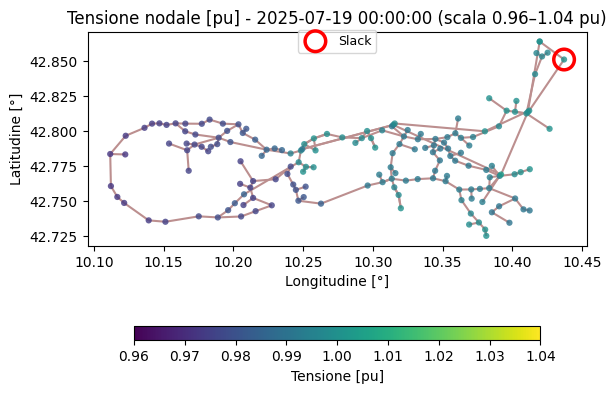

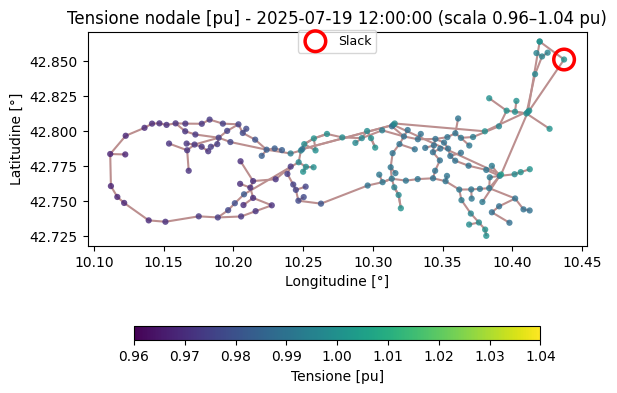

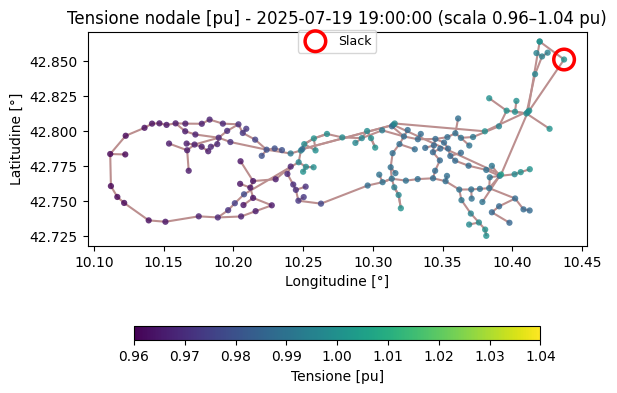

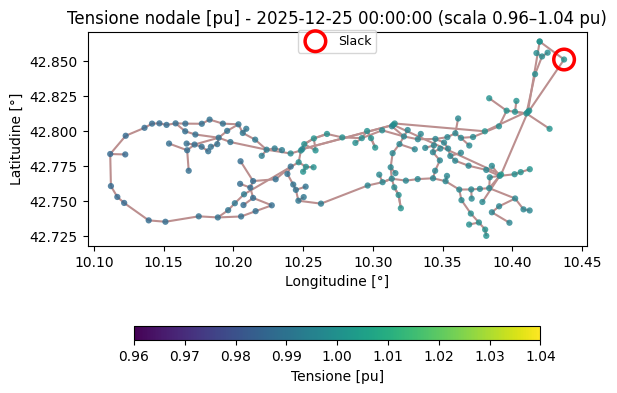

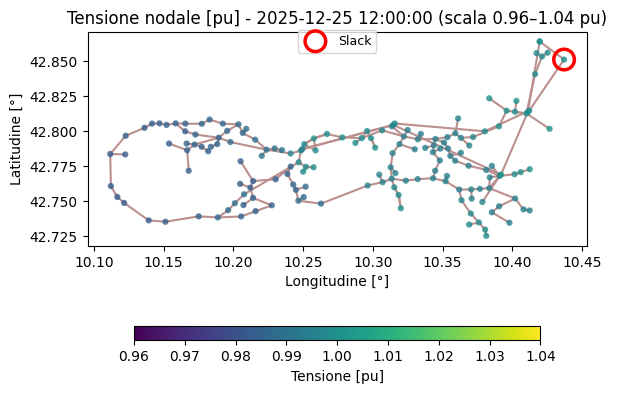

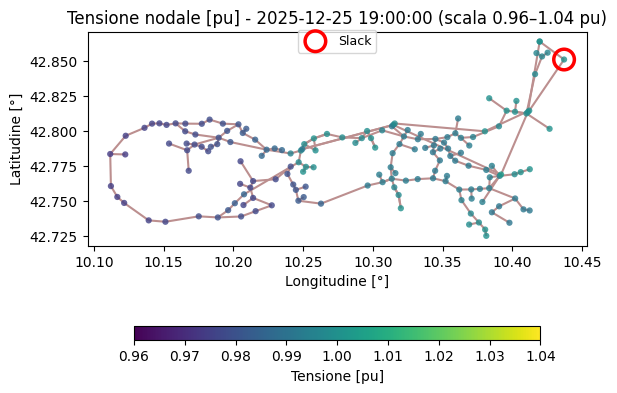

In [34]:
vmin = 0.96
vmax = 1.04

BUS_SLACK = ["microgrid_1_bus_124"]

highlight = {
    "Slack": {
        "buses": BUS_SLACK,
        "edgecolor": "red",
        "marker": "o",
        "s": 220,
        "lw": 2.5,
    },
}

for sns in n_mod.snapshots:
    v = n_mod.buses_t.v_mag_pu.loc[sns].reindex(n_mod.buses.index)

    fig, ax = plot_buses_map(
        n_mod, v,
        vmin=vmin, vmax=vmax,
        cbar_label="Tensione [pu]",
        cbar_orientation="horizontal",
        highlight=highlight
    )

    ax.set_title(f"Tensione nodale [pu] - {sns} (scala {vmin}–{vmax} pu)")
    plt.show()

In [37]:
# RIMOZIONE DEL VINCOLO s_max_pu SULLE LINEE

if "s_max_pu" in n_mod.lines.columns:
    n_mod.lines["s_max_pu"] = 1.0
    print("Colonna s_max_pu trovata: impostata a 1.0 per tutte le linee.")
else:
    print("La colonna s_max_pu non è presente nelle linee.")

Colonna s_max_pu trovata: impostata a 1.0 per tutte le linee.


In [ ]:
S = np.sqrt(n_mod.lines_t.p0**2 + n_mod.lines_t.q0**2)
loading = S.divide(n_mod.lines.s_nom, axis=1)

critical = [
    "0",
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_0",
    "connector_15kV_microgrid_1_bus_126_microgrid_1_bus_33"
]

print(loading[critical])
print("\nMassimo loading:")
print(loading[critical].max())

                            0  \
snapshot                        
2025-07-19 00:00:00  0.483938   
2025-07-19 12:00:00  0.582230   
2025-07-19 19:00:00  0.696266   
2025-12-25 00:00:00  0.242640   
2025-12-25 12:00:00  0.314522   
2025-12-25 19:00:00  0.456693   

                     connector_15kV_microgrid_1_bus_126_microgrid_1_bus_0  \
snapshot                                                                    
2025-07-19 00:00:00                                           0.532408      
2025-07-19 12:00:00                                           0.640278      
2025-07-19 19:00:00                                           0.765357      
2025-12-25 00:00:00                                           0.267161      
2025-12-25 12:00:00                                           0.346219      
2025-12-25 19:00:00                                           0.502485      

                     connector_15kV_microgrid_1_bus_126_microgrid_1_bus_33  
snapshot                                 

SCENARIO EVOLUTO

SCELTA DI 30 NODI CON TENSIONE MINIMA NEI VARI SNAPSHOT----> NODI SCELTI PER CALCOLARE L' HOSTING CAPACITY DELLA RETE

In [42]:
import pandas as pd

top_n = 30
ranking_list = []

vmag = n_mod.buses_t.v_mag_pu.copy()

# vmag = vmag.loc[:, n_mod.buses[n_mod.buses.v_nom <= 30].index]

for snap in vmag.index:
    voltages = vmag.loc[snap].dropna().sort_values()

    if voltages.empty:
        print(f"Nessun dato per snapshot {snap}")
        continue

    worst_buses = voltages.head(top_n)

    for rank, (bus, vpu) in enumerate(worst_buses.items(), start=1):
        ranking_list.append({
            "snapshot": snap,
            "rank": rank,
            "bus": bus,
            "v_mag_pu": vpu,
            "v_nom_kV": n_mod.buses.loc[bus, "v_nom"]
        })

ranking_df = pd.DataFrame(ranking_list)

print("\nTop 30 nodi più critici per ogni snapshot:")
print(ranking_df)


Top 30 nodi più critici per ogni snapshot:
               snapshot  rank                  bus  v_mag_pu  v_nom_kV
0   2025-07-19 00:00:00     1   microgrid_1_bus_77  0.972319      15.0
1   2025-07-19 00:00:00     2   microgrid_1_bus_29  0.972408      15.0
2   2025-07-19 00:00:00     3   microgrid_1_bus_19  0.972489      15.0
3   2025-07-19 00:00:00     4   microgrid_1_bus_85  0.972603      15.0
4   2025-07-19 00:00:00     5   microgrid_1_bus_20  0.972733      15.0
..                  ...   ...                  ...       ...       ...
175 2025-12-25 19:00:00    26  microgrid_1_bus_145  0.977189      15.0
176 2025-12-25 19:00:00    27   microgrid_1_bus_81  0.977280      15.0
177 2025-12-25 19:00:00    28   microgrid_1_bus_82  0.977280      15.0
178 2025-12-25 19:00:00    29   microgrid_1_bus_27  0.977356      15.0
179 2025-12-25 19:00:00    30   microgrid_1_bus_91  0.977417      15.0

[180 rows x 5 columns]


In [44]:
candidate_buses = [
    'microgrid_1_bus_106',
    'microgrid_1_bus_107',
    'microgrid_1_bus_91',
    'microgrid_1_bus_90',
    'microgrid_1_bus_89',
    'microgrid_1_bus_85',
    'microgrid_1_bus_84',
    'microgrid_1_bus_82',
    'microgrid_1_bus_81',
    'microgrid_1_bus_79',
    'microgrid_1_bus_78',
    'microgrid_1_bus_77',
    'microgrid_1_bus_74',
    'microgrid_1_bus_7',
    'microgrid_1_bus_30',
    'microgrid_1_bus_29',
    'microgrid_1_bus_28',
    'microgrid_1_bus_27',
    'microgrid_1_bus_26',
    'microgrid_1_bus_24',
    'microgrid_1_bus_23',
    'microgrid_1_bus_21',
    'microgrid_1_bus_20',
    'microgrid_1_bus_19',
    'microgrid_1_bus_149',
    'microgrid_1_bus_148',
    'microgrid_1_bus_145',
    'microgrid_1_bus_131',
    'microgrid_1_bus_129',
    'microgrid_1_bus_92'
]

print(len(candidate_buses))  # deve stampare 30

30


CALCOLO DELLA HOSTING CAPACITY AGGREGATA

In [ ]:
import copy


# 1) SNAPSHOT DA ANALIZZARE

selected_snaps = pd.DatetimeIndex([
    "2025-07-19 00:00:00",
    "2025-07-19 12:00:00",
    "2025-07-19 19:00:00",
    "2025-12-25 00:00:00",
    "2025-12-25 12:00:00",
    "2025-12-25 19:00:00"
])

network_snaps = pd.DatetimeIndex(n_mod.snapshots)
valid_snaps = selected_snaps.intersection(network_snaps)

if len(valid_snaps) == 0:
    raise ValueError("Nessuno degli snapshot richiesti è presente in n_mod.snapshots")

print("Snapshot usati:", list(valid_snaps))


# 2) LIMITI DI RETE

v_min_lim = 0.96
v_max_lim = 1.04
line_loading_lim = 1.00
trafo_loading_lim = 1.00


# 3) MIX FV / EOLICO
#    Nessun supporto reattivo: Q = 0

pv_share = 0.5
wind_share = 0.5
assert abs(pv_share + wind_share - 1.0) < 1e-9, "pv_share + wind_share deve fare 1"


# 4) PARAMETRI RICERCA HOSTING CAPACITY AGGREGATA

step_mw = 2.0
max_total_mw = 300.0
bisection_iter = 20
bisection_tol_mw = 0.01


# 5) 30 NODI CANDIDATI

candidate_buses = [
    'microgrid_1_bus_106',
    'microgrid_1_bus_107',
    'microgrid_1_bus_91',
    'microgrid_1_bus_90',
    'microgrid_1_bus_89',
    'microgrid_1_bus_85',
    'microgrid_1_bus_84',
    'microgrid_1_bus_82',
    'microgrid_1_bus_81',
    'microgrid_1_bus_79',
    'microgrid_1_bus_78',
    'microgrid_1_bus_77',
    'microgrid_1_bus_74',
    'microgrid_1_bus_7',
    'microgrid_1_bus_30',
    'microgrid_1_bus_29',
    'microgrid_1_bus_28',
    'microgrid_1_bus_27',
    'microgrid_1_bus_26',
    'microgrid_1_bus_24',
    'microgrid_1_bus_23',
    'microgrid_1_bus_21',
    'microgrid_1_bus_20',
    'microgrid_1_bus_19',
    'microgrid_1_bus_149',
    'microgrid_1_bus_148',
    'microgrid_1_bus_145',
    'microgrid_1_bus_131',
    'microgrid_1_bus_129',
    'microgrid_1_bus_92'
]

candidate_buses = [b for b in candidate_buses if b in n_mod.buses.index]

if len(candidate_buses) == 0:
    raise ValueError("Nessun candidate_bus presente in n_mod.buses.index")

print("Bus candidati:", len(candidate_buses))

# 6) CAPACITY FACTOR CORRETTI

pv_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.00,
    pd.Timestamp("2025-07-19 12:00:00"): 0.71,
    pd.Timestamp("2025-07-19 19:00:00"): 0.16,
    pd.Timestamp("2025-12-25 00:00:00"): 0.00,
    pd.Timestamp("2025-12-25 12:00:00"): 0.50,
    pd.Timestamp("2025-12-25 19:00:00"): 0.00,
}).reindex(n_mod.snapshots).fillna(0.0)

wind_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.12,
    pd.Timestamp("2025-07-19 12:00:00"): 0.12,
    pd.Timestamp("2025-07-19 19:00:00"): 0.14,
    pd.Timestamp("2025-12-25 00:00:00"): 0.18,
    pd.Timestamp("2025-12-25 12:00:00"): 0.18,
    pd.Timestamp("2025-12-25 19:00:00"): 0.19,
}).reindex(n_mod.snapshots).fillna(0.0)

cf_pv = pv_cf.loc[valid_snaps].clip(lower=0.0, upper=1.0)
cf_wind = wind_cf.loc[valid_snaps].clip(lower=0.0, upper=1.0)

print("\nCF fotovoltaico:")
print(cf_pv)

print("\nCF eolico:")
print(cf_wind)

# 7) PESI DI DISTRIBUZIONE
#    Uniformi sui 30 nodi

weights = pd.Series(1.0, index=candidate_buses, dtype=float)
weights = weights / weights.sum()

print("\nPotenza ripartita uniformemente sui nodi candidati.")

# 8) FUNZIONI DI SUPPORTO

def compute_line_loading(n, snaps):
    if n.lines.empty:
        return 0.0

    s_nom = n.lines.s_nom.replace(0, np.nan)

    if "q0" in n.lines_t and not n.lines_t.q0.empty:
        s_from = np.sqrt(n.lines_t.p0.loc[snaps]**2 + n.lines_t.q0.loc[snaps]**2)
    else:
        s_from = n.lines_t.p0.loc[snaps].abs()

    loading = s_from.div(s_nom, axis=1)
    loading = loading.replace([np.inf, -np.inf], np.nan)

    max_loading = float(np.nanmax(loading.values)) if loading.size else 0.0
    if np.isnan(max_loading):
        max_loading = 0.0
    return max_loading


def compute_trafo_loading(n, snaps):
    if n.transformers.empty:
        return 0.0

    s_nom = n.transformers.s_nom.replace(0, np.nan)

    if "q0" in n.transformers_t and not n.transformers_t.q0.empty:
        s_from = np.sqrt(n.transformers_t.p0.loc[snaps]**2 + n.transformers_t.q0.loc[snaps]**2)
    else:
        s_from = n.transformers_t.p0.loc[snaps].abs()

    loading = s_from.div(s_nom, axis=1)
    loading = loading.replace([np.inf, -np.inf], np.nan)

    max_loading = float(np.nanmax(loading.values)) if loading.size else 0.0
    if np.isnan(max_loading):
        max_loading = 0.0
    return max_loading


def run_pf_and_check(n, snaps, vmin_lim, vmax_lim, line_lim, trafo_lim):
    n.pf(snapshots=snaps, use_seed=True)

    V = n.buses_t.v_mag_pu.loc[snaps]
    vmin = float(V.min().min())
    vmax = float(V.max().max())

    max_line_loading = compute_line_loading(n, snaps)
    max_trafo_loading = compute_trafo_loading(n, snaps)

    ok = (
        (vmin >= vmin_lim) and
        (vmax <= vmax_lim) and
        (max_line_loading <= line_lim) and
        (max_trafo_loading <= trafo_lim)
    )

    return ok, vmin, vmax, max_line_loading, max_trafo_loading


# 9) AGGIUNTA GENERATORI DISTRIBUITI SU TUTTI I 30 NODI
#    q_set = 0 -> niente reattiva

def add_res_generators_distributed(
    n, buses, total_p_nom_mw, weights, snaps, cf_pv, cf_wind,
    pv_share=0.5, wind_share=0.5, prefix="HC"
):
    total_pv_nom = total_p_nom_mw * pv_share
    total_wind_nom = total_p_nom_mw * wind_share

    for b in buses:
        w = float(weights[b])

        pv_nom = total_pv_nom * w
        wind_nom = total_wind_nom * w

        pv_name = f"{prefix}_PV_{b}"
        wd_name = f"{prefix}_WIND_{b}"

        n.add(
            "Generator",
            pv_name,
            bus=b,
            p_nom=pv_nom,
            marginal_cost=0.0,
            control="PQ",
            carrier="solar"
        )

        n.add(
            "Generator",
            wd_name,
            bus=b,
            p_nom=wind_nom,
            marginal_cost=0.0,
            control="PQ",
            carrier="wind"
        )

        # Potenza attiva ai vari snapshot
        n.generators_t.p_set.loc[snaps, pv_name] = pv_nom * cf_pv.loc[snaps].values
        n.generators_t.p_set.loc[snaps, wd_name] = wind_nom * cf_wind.loc[snaps].values

        # Nessuna potenza reattiva
        n.generators_t.q_set.loc[snaps, pv_name] = 0.0
        n.generators_t.q_set.loc[snaps, wd_name] = 0.0


def build_and_check_distributed(total_mw, prefix="HC"):
    n_test = copy.deepcopy(n_mod)

    add_res_generators_distributed(
        n=n_test,
        buses=candidate_buses,
        total_p_nom_mw=total_mw,
        weights=weights,
        snaps=valid_snaps,
        cf_pv=cf_pv,
        cf_wind=cf_wind,
        pv_share=pv_share,
        wind_share=wind_share,
        prefix=prefix
    )

    return run_pf_and_check(
        n=n_test,
        snaps=valid_snaps,
        vmin_lim=v_min_lim,
        vmax_lim=v_max_lim,
        line_lim=line_loading_lim,
        trafo_lim=trafo_loading_lim
    )


# 10) RICERCA HOSTING CAPACITY AGGREGATA

results = []
last_ok = 0.0
first_bad = None

total = 0.0
while total < max_total_mw:
    total += step_mw

    ok, vmin, vmax, line_load, trafo_load = build_and_check_distributed(
        total_mw=total,
        prefix=f"HC_{int(total*1000)}"
    )

    results.append({
        "P_total_MW": total,
        "P_PV_MW": total * pv_share,
        "P_WIND_MW": total * wind_share,
        "P_per_bus_avg_MW": total / len(candidate_buses),
        "ok": ok,
        "vmin": vmin,
        "vmax": vmax,
        "line_loading_max_pu": line_load,
        "trafo_loading_max_pu": trafo_load
    })

    print(
        f"Ptot={total:.2f} MW | "
        f"Pmed_bus={total/len(candidate_buses):.3f} MW | "
        f"ok={ok} | Vmin={vmin:.4f} | Vmax={vmax:.4f} | "
        f"Line={line_load:.4f} | Trafo={trafo_load:.4f}"
    )

    if ok:
        last_ok = total
    else:
        first_bad = total
        break

results_df = pd.DataFrame(results)


# 11) BISEZIONE FINALE

if first_bad is not None:
    low = last_ok
    high = first_bad

    for _ in range(bisection_iter):
        mid = 0.5 * (low + high)

        ok, vmin, vmax, line_load, trafo_load = build_and_check_distributed(
            total_mw=mid,
            prefix=f"HC_BIS_{int(mid*1000)}"
        )

        if ok:
            low = mid
        else:
            high = mid

        if (high - low) < bisection_tol_mw:
            break

    hc_final = low
    ok, vmin, vmax, line_load, trafo_load = build_and_check_distributed(
        total_mw=hc_final,
        prefix="HC_FINAL"
    )

    print("\n==============================")
    print(f"HOSTING CAPACITY AGGREGATA = {hc_final:.3f} MW")
    print(f" - FV installabile         = {hc_final * pv_share:.3f} MW")
    print(f" - Eolico installabile     = {hc_final * wind_share:.3f} MW")
    print(f" - Nodi candidati          = {len(candidate_buses)}")
    print(f" - Potenza media per nodo  = {hc_final / len(candidate_buses):.3f} MW")
    print(f" - Snapshot usati          = {len(valid_snaps)}")
    print(f" - Vmin finale             = {vmin:.4f}")
    print(f" - Vmax finale             = {vmax:.4f}")
    print(f" - Max line loading        = {line_load:.4f} p.u.")
    print(f" - Max trafo loading       = {trafo_load:.4f} p.u.")
    print("==============================")
else:
    hc_final = last_ok
    print("\nNessuna violazione trovata entro max_total_mw")
    print(f"Hosting capacity aggregata almeno = {hc_final:.3f} MW")

display(results_df)

Snapshot usati: [Timestamp('2025-07-19 00:00:00'), Timestamp('2025-07-19 12:00:00'), Timestamp('2025-07-19 19:00:00'), Timestamp('2025-12-25 00:00:00'), Timestamp('2025-12-25 12:00:00'), Timestamp('2025-12-25 19:00:00')]
Bus candidati: 30

CF fotovoltaico:
2025-07-19 00:00:00    0.00
2025-07-19 12:00:00    0.71
2025-07-19 19:00:00    0.16
2025-12-25 00:00:00    0.00
2025-12-25 12:00:00    0.50
2025-12-25 19:00:00    0.00
dtype: float64

CF eolico:
2025-07-19 00:00:00    0.12
2025-07-19 12:00:00    0.12
2025-07-19 19:00:00    0.14
2025-12-25 00:00:00    0.18
2025-12-25 12:00:00    0.18
2025-12-25 19:00:00    0.19
dtype: float64

Potenza ripartita uniformemente sui nodi candidati.


INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 00:00:00', '2025-07-19 12:00:00',
               '2025-07-19 19:00:00', '2025-12-25 00:00:00',
               '2025-12-25 12:00:00', '2025-12-25 19:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupb

Ptot=2.00 MW | Pmed_bus=0.067 MW | ok=True | Vmin=0.9616 | Vmax=1.0042 | Line=0.9587 | Trafo=0.4478


INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 00:00:00', '2025-07-19 12:00:00',
               '2025-07-19 19:00:00', '2025-12-25 00:00:00',
               '2025-12-25 12:00:00', '2025-12-25 19:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupb

Ptot=4.00 MW | Pmed_bus=0.133 MW | ok=True | Vmin=0.9631 | Vmax=1.0042 | Line=0.9475 | Trafo=0.4421


...

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 00:00:00', '2025-07-19 12:00:00',
               '2025-07-19 19:00:00', '2025-12-25 00:00:00',
               '2025-12-25 12:00:00', '2025-12-25 19:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupb

Ptot=40.00 MW | Pmed_bus=1.333 MW | ok=False | Vmin=0.9838 | Vmax=1.0422 | Line=0.7533 | Trafo=0.3437


INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 00:00:00', '2025-07-19 12:00:00',
               '2025-07-19 19:00:00', '2025-12-25 00:00:00',
               '2025-12-25 12:00:00', '2025-12-25 19:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupb


HOSTING CAPACITY AGGREGATA = 38.391 MW
 - FV installabile         = 19.195 MW
 - Eolico installabile     = 19.195 MW
 - Nodi candidati          = 30
 - Potenza media per nodo  = 1.280 MW
 - Snapshot usati          = 6
 - Vmin finale             = 0.9835
 - Vmax finale             = 1.0400
 - Max line loading        = 0.7616 p.u.
 - Max trafo loading       = 0.3480 p.u.


,P_total_MW,P_PV_MW,P_WIND_MW,P_per_bus_avg_MW,ok,vmin,vmax,line_loading_max_pu,trafo_loading_max_pu
0,2.0,1.0,1.0,0.066667,True,0.961557,1.004231,0.958734,0.447800
1,4.0,2.0,2.0,0.133333,True,0.963089,1.004170,0.947508,0.442129
2,6.0,3.0,3.0,0.200000,True,0.964613,1.004108,0.936330,0.436480
3,8.0,4.0,4.0,0.266667,True,0.966130,1.004046,0.925201,0.430855
4,10.0,5.0,5.0,0.333333,True,0.967639,1.003983,0.914119,0.425251
5,12.0,6.0,6.0,0.400000,True,0.969141,1.003919,0.903083,0.419670
6,14.0,7.0,7.0,0.466667,True,0.970636,1.004856,0.892094,0.414111
7,16.0,8.0,8.0,0.533333,True,0.972123,1.007893,0.881152,0.408574
8,18.0,9.0,9.0,0.600000,True,0.973603,1.010899,0.870254,0.403058
9,20.0,10.0,10.0,0.666667,True,0.975076,1.013877,0.859402,0.397564


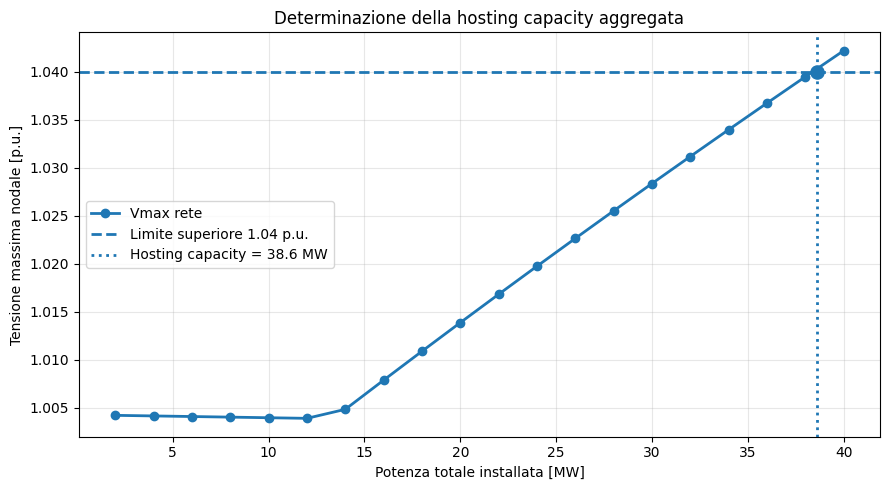

In [ ]:
import matplotlib.pyplot as plt

#GRAFICO 1 - HOSTING CAPACITY: Vmax vs P installata


hc_final = 38.6  # oppure usa il valore calcolato automaticamente: hc_final

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    results_df["P_total_MW"],
    results_df["vmax"],
    marker="o",
    linewidth=2,
    label="Vmax rete"
)

# Limite superiore di tensione
ax.axhline(
    y=v_max_lim,
    linestyle="--",
    linewidth=2,
    label="Limite superiore 1.04 p.u."
)

# Hosting capacity
ax.axvline(
    x=hc_final,
    linestyle=":",
    linewidth=2,
    label=f"Hosting capacity = {hc_final:.1f} MW"
)

ax.scatter(
    hc_final,
    v_max_lim,
    s=90,
    zorder=5
)

ax.set_xlabel("Potenza totale installata [MW]")
ax.set_ylabel("Tensione massima nodale [p.u.]")
ax.set_title("Determinazione della hosting capacity aggregata")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("hc_vmax_vs_pinstalled.png", dpi=300, bbox_inches="tight")
plt.show()

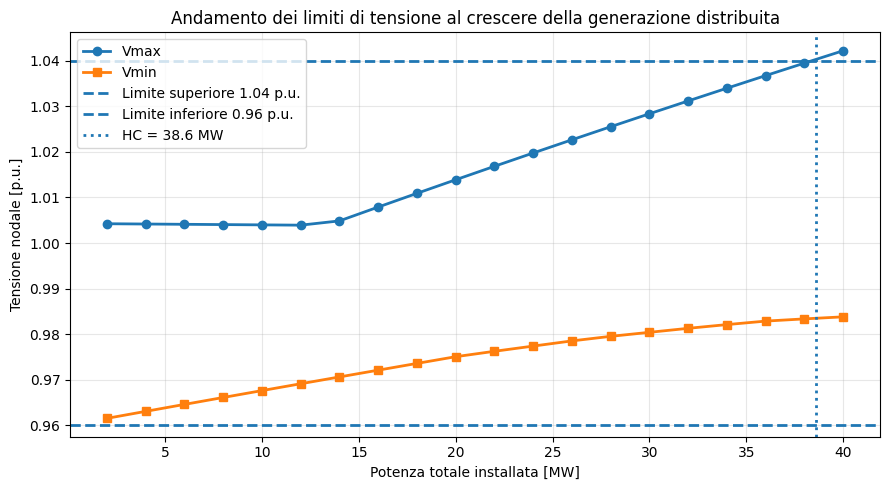

In [ ]:
# GRAFICO 2 - Vmin e Vmax vs P installata

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    results_df["P_total_MW"],
    results_df["vmax"],
    marker="o",
    linewidth=2,
    label="Vmax"
)

ax.plot(
    results_df["P_total_MW"],
    results_df["vmin"],
    marker="s",
    linewidth=2,
    label="Vmin"
)

ax.axhline(
    y=v_max_lim,
    linestyle="--",
    linewidth=2,
    label="Limite superiore 1.04 p.u."
)

ax.axhline(
    y=v_min_lim,
    linestyle="--",
    linewidth=2,
    label="Limite inferiore 0.96 p.u."
)

ax.axvline(
    x=hc_final,
    linestyle=":",
    linewidth=2,
    label=f"HC = {hc_final:.1f} MW"
)

ax.set_xlabel("Potenza totale installata [MW]")
ax.set_ylabel("Tensione nodale [p.u.]")
ax.set_title("Andamento dei limiti di tensione al crescere della generazione distribuita")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("hc_vmin_vmax_vs_pinstalled.png", dpi=300, bbox_inches="tight")
plt.show()

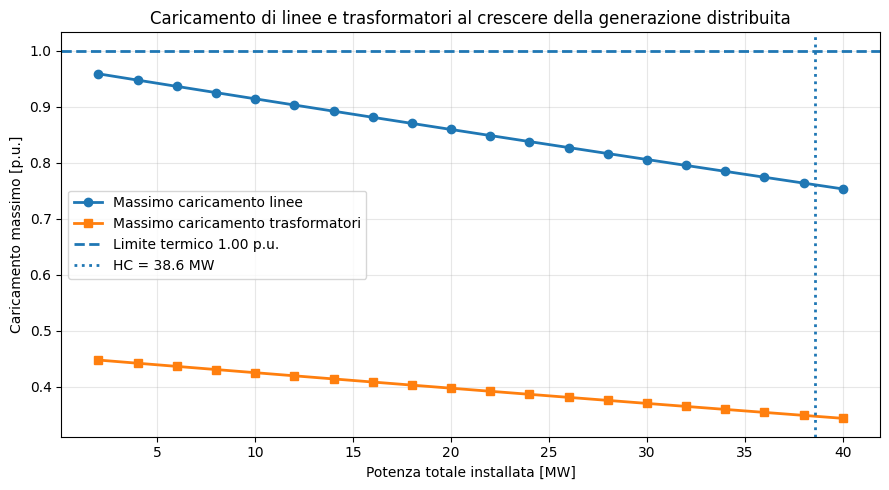

In [ ]:

# GRAFICO 3 - Caricamento linee e trasformatori


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    results_df["P_total_MW"],
    results_df["line_loading_max_pu"],
    marker="o",
    linewidth=2,
    label="Massimo caricamento linee"
)

ax.plot(
    results_df["P_total_MW"],
    results_df["trafo_loading_max_pu"],
    marker="s",
    linewidth=2,
    label="Massimo caricamento trasformatori"
)

ax.axhline(
    y=1.0,
    linestyle="--",
    linewidth=2,
    label="Limite termico 1.00 p.u."
)

ax.axvline(
    x=hc_final,
    linestyle=":",
    linewidth=2,
    label=f"HC = {hc_final:.1f} MW"
)

ax.set_xlabel("Potenza totale installata [MW]")
ax.set_ylabel("Caricamento massimo [p.u.]")
ax.set_title("Caricamento di linee e trasformatori al crescere della generazione distribuita")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("hc_loading_vs_pinstalled.png", dpi=300, bbox_inches="tight")
plt.show()

INSTALLAZIONE DI NUOVA GENERAZIONE DISTRIBUITA A SEGUITO DEL CALCOLO DELLA HOSTING CAPACITY

In [ ]:

# 1) NODI SELEZIONATI
fv_wind_buses = [
    'microgrid_1_bus_106',
    'microgrid_1_bus_107',
    'microgrid_1_bus_91',
    'microgrid_1_bus_90',
    'microgrid_1_bus_89',
    'microgrid_1_bus_85',
    'microgrid_1_bus_84',
    'microgrid_1_bus_82',
    'microgrid_1_bus_81',
    'microgrid_1_bus_79',
    'microgrid_1_bus_78',
    'microgrid_1_bus_77',
    'microgrid_1_bus_74',
    'microgrid_1_bus_7',
    'microgrid_1_bus_30',
    'microgrid_1_bus_29',
    'microgrid_1_bus_28',
    'microgrid_1_bus_27',
    'microgrid_1_bus_26',
    'microgrid_1_bus_24',
    'microgrid_1_bus_23',
    'microgrid_1_bus_21',
    'microgrid_1_bus_20',
    'microgrid_1_bus_19',
    'microgrid_1_bus_149',
    'microgrid_1_bus_148',
    'microgrid_1_bus_145',
    'microgrid_1_bus_131',
    'microgrid_1_bus_129',
    'microgrid_1_bus_92'
]

fv_wind_buses = [b for b in fv_wind_buses if b in n_mod.buses.index]

if len(fv_wind_buses) == 0:
    raise ValueError("Nessun bus selezionato presente in n_mod.buses.index")


# 2) POTENZA EXTRA DA INSTALLARE

PV_EXTRA_TOTAL_MW   = 19.281
WIND_EXTRA_TOTAL_MW = 19.281

pv_extra_per_bus_mw   = PV_EXTRA_TOTAL_MW / len(fv_wind_buses)
wind_extra_per_bus_mw = WIND_EXTRA_TOTAL_MW / len(fv_wind_buses)

print(f"Numero bus candidati: {len(fv_wind_buses)}")
print(f"Extra FV totale [MW]:   {PV_EXTRA_TOTAL_MW:.3f}")
print(f"Extra Wind totale [MW]: {WIND_EXTRA_TOTAL_MW:.3f}")
print(f"Extra FV per bus [MW]:  {pv_extra_per_bus_mw:.6f}")
print(f"Extra Wind per bus [MW]: {wind_extra_per_bus_mw:.6f}")

# 3) CHECK BUS MANCANTI

missing_buses = [b for b in fv_wind_buses if b not in n_mod.buses.index]
if len(missing_buses) > 0:
    raise ValueError(f"Bus non trovati in rete: {missing_buses}")

# 4) RIMOZIONE EVENTUALI GENERATORI EXTRA GIÀ PRESENTI

extra_gens_to_remove = []

for bus_name in fv_wind_buses:
    g_pv = f"solar_extra_{bus_name}"
    g_wind = f"wind_extra_{bus_name}"

    if g_pv in n_mod.generators.index:
        extra_gens_to_remove.append(g_pv)
    if g_wind in n_mod.generators.index:
        extra_gens_to_remove.append(g_wind)

if len(extra_gens_to_remove) > 0:
    n_mod.remove("Generator", extra_gens_to_remove)
    print("\nRimossi generatori extra già esistenti:")
    print(extra_gens_to_remove)


# 5) AGGIUNTA NUOVI GENERATORI EXTRA
#    Nessun supporto reattivo
for bus_name in fv_wind_buses:
    n_mod.add(
        "Generator",
        name=f"solar_extra_{bus_name}",
        bus=bus_name,
        carrier="solar",
        control="PQ",
        p_nom=pv_extra_per_bus_mw,
        marginal_cost=0.0
    )

    n_mod.add(
        "Generator",
        name=f"wind_extra_{bus_name}",
        bus=bus_name,
        carrier="wind",
        control="PQ",
        p_nom=wind_extra_per_bus_mw,
        marginal_cost=0.0
    )

extra_solar_gens = [f"solar_extra_{b}" for b in fv_wind_buses]
extra_wind_gens  = [f"wind_extra_{b}" for b in fv_wind_buses]
extra_res_gens   = extra_solar_gens + extra_wind_gens


# 6) CAPACITY FACTOR

pv_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.00,
    pd.Timestamp("2025-07-19 12:00:00"): 0.71,
    pd.Timestamp("2025-07-19 19:00:00"): 0.16,
    pd.Timestamp("2025-12-25 00:00:00"): 0.00,
    pd.Timestamp("2025-12-25 12:00:00"): 0.50,
    pd.Timestamp("2025-12-25 19:00:00"): 0.00,
}).reindex(n_mod.snapshots).fillna(0.0)

wind_cf = pd.Series({
    pd.Timestamp("2025-07-19 00:00:00"): 0.12,
    pd.Timestamp("2025-07-19 12:00:00"): 0.12,
    pd.Timestamp("2025-07-19 19:00:00"): 0.14,
    pd.Timestamp("2025-12-25 00:00:00"): 0.18,
    pd.Timestamp("2025-12-25 12:00:00"): 0.18,
    pd.Timestamp("2025-12-25 19:00:00"): 0.19,
}).reindex(n_mod.snapshots).fillna(0.0)


# 7) AGGIORNAMENTO p_max_pu

if n_mod.generators_t.p_max_pu.empty:
    n_mod.generators_t.p_max_pu = pd.DataFrame(index=n_mod.snapshots)

for g in extra_res_gens:
    if g not in n_mod.generators_t.p_max_pu.columns:
        n_mod.generators_t.p_max_pu[g] = 1.0

for g in extra_solar_gens:
    n_mod.generators_t.p_max_pu.loc[:, g] = pv_cf.values

for g in extra_wind_gens:
    n_mod.generators_t.p_max_pu.loc[:, g] = wind_cf.values

# 8) AGGIORNAMENTO p_set

if n_mod.generators_t.p_set.empty:
    n_mod.generators_t.p_set = pd.DataFrame(index=n_mod.snapshots)

for g in extra_res_gens:
    if g not in n_mod.generators_t.p_set.columns:
        n_mod.generators_t.p_set[g] = 0.0

for g in extra_solar_gens:
    n_mod.generators_t.p_set.loc[:, g] = (
        float(n_mod.generators.at[g, "p_nom"]) * pv_cf.values
    )

for g in extra_wind_gens:
    n_mod.generators_t.p_set.loc[:, g] = (
        float(n_mod.generators.at[g, "p_nom"]) * wind_cf.values
    )

# 9) AGGIORNAMENTO q_set = 0
#    Nessuna potenza reattiva

if n_mod.generators_t.q_set.empty:
    n_mod.generators_t.q_set = pd.DataFrame(index=n_mod.snapshots)

for g in extra_res_gens:
    if g not in n_mod.generators_t.q_set.columns:
        n_mod.generators_t.q_set[g] = 0.0

n_mod.generators_t.q_set.loc[:, extra_res_gens] = 0.0


# 10) CHECK FINALI

print("\n=== GENERATORI EXTRA AGGIUNTI ===")
display(n_mod.generators.loc[extra_res_gens, ["bus", "carrier", "p_nom"]])

# totale FV complessivo nel sistema
total_pv = float(
    n_mod.generators.loc[n_mod.generators.carrier == "solar", "p_nom"].sum()
)

# totale eolico complessivo nel sistema
wind_carriers = ["onwind", "wind"]
wind_mask = n_mod.generators.carrier.isin(wind_carriers)
total_wind = float(
    n_mod.generators.loc[wind_mask, "p_nom"].sum()
)

print("\n=== TOTALI AGGIORNATI NEL SISTEMA ===")
print(f"FV totale installato [MW]:   {total_pv:.3f}")
print(f"Wind totale installato [MW]: {total_wind:.3f}")
print(f"GEN totale installata [MW]:  {total_pv + total_wind:.3f}")

print("\n=== EXTRA INSTALLATA SUI 30 NODI ===")
print(f"Extra FV totale [MW]:    {PV_EXTRA_TOTAL_MW:.3f}")
print(f"Extra Wind totale [MW]:  {WIND_EXTRA_TOTAL_MW:.3f}")
print(f"Extra FV per bus [MW]:   {pv_extra_per_bus_mw:.6f}")
print(f"Extra Wind per bus [MW]: {wind_extra_per_bus_mw:.6f}")


# 11) CONTROLLO RAPIDO PRODUZIONE AI 6 SNAPSHOT
extra_p_active = n_mod.generators_t.p_set[extra_res_gens].sum(axis=1)
extra_q_active = n_mod.generators_t.q_set[extra_res_gens].sum(axis=1)

check_df = pd.DataFrame({
    "P_extra_total_MW": extra_p_active,
    "Q_extra_total_Mvar": extra_q_active
})

print("\n=== PRODUZIONE EXTRA AI VARI SNAPSHOT ===")
display(check_df)

Numero bus candidati: 30
Extra FV totale [MW]:   19.281
Extra Wind totale [MW]: 19.281
Extra FV per bus [MW]:  0.642700
Extra Wind per bus [MW]: 0.642700

=== GENERATORI EXTRA AGGIUNTI ===


,bus,carrier,p_nom
Generator,,,
solar_extra_microgrid_1_bus_106,microgrid_1_bus_106,solar,0.6427
solar_extra_microgrid_1_bus_107,microgrid_1_bus_107,solar,0.6427
solar_extra_microgrid_1_bus_91,microgrid_1_bus_91,solar,0.6427
solar_extra_microgrid_1_bus_90,microgrid_1_bus_90,solar,0.6427
solar_extra_microgrid_1_bus_89,microgrid_1_bus_89,solar,0.6427
solar_extra_microgrid_1_bus_85,microgrid_1_bus_85,solar,0.6427
solar_extra_microgrid_1_bus_84,microgrid_1_bus_84,solar,0.6427
solar_extra_microgrid_1_bus_82,microgrid_1_bus_82,solar,0.6427
solar_extra_microgrid_1_bus_81,microgrid_1_bus_81,solar,0.6427



=== TOTALI AGGIORNATI NEL SISTEMA ===
FV totale installato [MW]:   27.281
Wind totale installato [MW]: 19.281
GEN totale installata [MW]:  46.562

=== EXTRA INSTALLATA SUI 30 NODI ===
Extra FV totale [MW]:    19.281
Extra Wind totale [MW]:  19.281
Extra FV per bus [MW]:   0.642700
Extra Wind per bus [MW]: 0.642700

=== PRODUZIONE EXTRA AI VARI SNAPSHOT ===


,P_extra_total_MW,Q_extra_total_Mvar
snapshot,,
2025-07-19 00:00:00,2.31372,0.0
2025-07-19 12:00:00,16.00323,0.0
2025-07-19 19:00:00,5.78430,0.0
2025-12-25 00:00:00,3.47058,0.0
2025-12-25 12:00:00,13.11108,0.0
2025-12-25 19:00:00,3.66339,0.0


SCELTA DI NODI IN CENTRI URBAINI PER L'INSERIMENTO DI COLONNINE DI RICARICA PER VEICOLI ELETTRICI

In [50]:
ev_buses = [
    "microgrid_1_bus_73",
    "microgrid_1_bus_144",
    "microgrid_1_bus_143",
    "microgrid_1_bus_3",
    "microgrid_1_bus_33",
    "microgrid_1_bus_126",
    "microgrid_1_bus_43",
    "microgrid_1_bus_76",
    "microgrid_1_bus_87",
    "microgrid_1_bus_101",
    "microgrid_1_bus_105"
]

In [ ]:
# Parametri EV
p_per_node_mw = 0.22
cosphi = 0.98
phi = np.arccos(cosphi)
q_per_node_mvar = p_per_node_mw * np.tan(phi)

for bus_name in ev_buses:
    n_mod.add(
        "Load",
        name=f"EV_load_{bus_name}",
        bus=bus_name,
        p_set=p_per_node_mw,
        q_set=q_per_node_mvar
    )

RICALCOLO POWER FLOW PER SCENARIO DI RETE EVOLUTA

In [52]:
for sns in n_mod.snapshots:

    # inizializzazione con linear PF
    n_mod.lpf(snapshots=[sns])
    
    # AC power flow
    res = n_mod.pf(snapshots=[sns], use_seed=True)

    print("\nSnapshot:", sns)

    conv = bool(res["converged"].loc[sns].any())
    print("PF convergence:", conv)

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2025-07-19'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19'], dtype='datet


Snapshot: 2025-07-19 00:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-07-19 12:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 19:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=

...


Snapshot: 2025-12-25 00:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-12-25 12:00:00
PF convergence: True


c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:1507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-12-25 19:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis


Snapshot: 2025-12-25 19:00:00
PF convergence: True


In [53]:
for sns in n_mod.snapshots:
    v = n_mod.buses_t.v_mag_pu.loc[sns].dropna()

    print(f"\n{sns}")
    print("Vmin:", float(v.min()), "bus:", v.idxmin())
    print("Vmax:", float(v.max()), "bus:", v.idxmax())


2025-07-19 00:00:00
Vmin: 0.979827654144365 bus: microgrid_1_bus_38
Vmax: 1.0032429099133446 bus: microgrid_1_bus_34

2025-07-19 12:00:00
Vmin: 0.9898866039218693 bus: microgrid_1_bus_3
Vmax: 1.0371107570808968 bus: microgrid_1_bus_77

2025-07-19 19:00:00
Vmin: 0.979348324486141 bus: microgrid_1_bus_151
Vmax: 1.0033247798147766 bus: microgrid_1_bus_34

2025-12-25 00:00:00
Vmin: 0.9932413234023868 bus: microgrid_1_bus_151
Vmax: 1.0014745864647168 bus: microgrid_1_bus_34

2025-12-25 12:00:00
Vmin: 0.9945684255050597 bus: microgrid_1_bus_3
Vmax: 1.038660215007616 bus: microgrid_1_bus_77

2025-12-25 19:00:00
Vmin: 0.9845898129049352 bus: microgrid_1_bus_105
Vmax: 1.0027599790059964 bus: microgrid_1_bus_34


In [54]:
v = n_mod.buses_t.v_mag_pu.copy()

# min/max per snapshot
summary = pd.DataFrame({
    "v_min": v.min(axis=1),
    "v_max": v.max(axis=1),
    "v_mean": v.mean(axis=1),
    "v_std": v.std(axis=1),
})
print(summary)

# differenza massima tra snapshot consecutivi
snap = n_mod.snapshots
for i in range(1, len(snap)):
    d = (v.loc[snap[i]] - v.loc[snap[i-1]]).abs()
    print(f"Δmax {snap[i-1]} -> {snap[i]} = {d.max():.6f} pu | Δmean = {d.mean():.6f} pu")

                        v_min     v_max    v_mean     v_std
snapshot                                                   
2025-07-19 00:00:00  0.979828  1.003243  0.990558  0.006578
2025-07-19 12:00:00  0.989887  1.037111  1.005115  0.013592
2025-07-19 19:00:00  0.979348  1.003325  0.990192  0.005702
2025-12-25 00:00:00  0.993241  1.001475  0.997879  0.001767
2025-12-25 12:00:00  0.994568  1.038660  1.007574  0.013540
2025-12-25 19:00:00  0.984590  1.002760  0.993049  0.004257
Δmax 2025-07-19 00:00:00 -> 2025-07-19 12:00:00 = 0.055322 pu | Δmean = 0.014650 pu
Δmax 2025-07-19 12:00:00 -> 2025-07-19 19:00:00 = 0.050509 pu | Δmean = 0.014963 pu
Δmax 2025-07-19 19:00:00 -> 2025-12-25 00:00:00 = 0.014769 pu | Δmean = 0.007709 pu
Δmax 2025-12-25 00:00:00 -> 2025-12-25 12:00:00 = 0.037726 pu | Δmean = 0.009829 pu
Δmax 2025-12-25 12:00:00 -> 2025-12-25 19:00:00 = 0.048902 pu | Δmean = 0.014571 pu


In [ ]:
# 1) SNAPSHOT DA ANALIZZARE
selected_snaps = pd.DatetimeIndex([
    "2025-07-19 00:00:00",
    "2025-07-19 12:00:00",
    "2025-07-19 19:00:00",
    "2025-12-25 00:00:00",
    "2025-12-25 12:00:00",
    "2025-12-25 19:00:00"
])

valid_snaps = selected_snaps.intersection(n_mod.snapshots)

if len(valid_snaps) == 0:
    raise ValueError("Nessuno degli snapshot richiesti è presente in n_mod.snapshots")

print("Snapshot usati:", list(valid_snaps))

# 2) ESEGUI POWER FLOW
n_mod.pf(snapshots=valid_snaps, use_seed=True)

# 3) INDIVIDUAZIONE GENERATORI RINNOVABILI
res_carriers = ["solar", "wind", "onwind"]
res_gens = n_mod.generators.index[n_mod.generators.carrier.isin(res_carriers)].tolist()

print("\nNumero generatori rinnovabili trovati:", len(res_gens))


# 4) INDIVIDUAZIONE GENERATORI DI SCAMBIO CON LA RETE
#    prima prova: generatori Slack
#    fallback: carrier/nome contenente 'grid'

gen_control = n_mod.generators["control"].astype(str).str.lower()
slack_gens = n_mod.generators.index[gen_control.eq("slack")].tolist()

if len(slack_gens) == 0:
    gen_name = n_mod.generators.index.to_series().astype(str).str.lower()
    gen_carrier = n_mod.generators["carrier"].astype(str).str.lower()
    mask_grid = (
        gen_name.str.contains("grid") |
        gen_name.str.contains("import") |
        gen_carrier.str.contains("grid") |
        gen_carrier.str.contains("import")
    )
    slack_gens = n_mod.generators.index[mask_grid].tolist()

print("Generatori di scambio con la rete trovati:", slack_gens)

if len(slack_gens) == 0:
    print("ATTENZIONE: non ho trovato generatori Slack/grid in modo automatico.")

# 5) CARICO TOTALE
# uso i risultati del PF se disponibili, altrimenti p_set
if hasattr(n_mod.loads_t, "p") and not n_mod.loads_t.p.empty:
    total_load = n_mod.loads_t.p.loc[valid_snaps].sum(axis=1)
else:
    total_load = n_mod.loads_t.p_set.loc[valid_snaps].sum(axis=1)


# 6) PRODUZIONE RINNOVABILE TOTALE
if len(res_gens) > 0:
    if hasattr(n_mod.generators_t, "p") and not n_mod.generators_t.p.empty:
        total_res_gen = n_mod.generators_t.p.loc[valid_snaps, res_gens].sum(axis=1)
    else:
        total_res_gen = n_mod.generators_t.p_set.loc[valid_snaps, res_gens].sum(axis=1)
else:
    total_res_gen = pd.Series(0.0, index=valid_snaps)

# dettaglio FV / eolico
solar_gens = n_mod.generators.index[n_mod.generators.carrier.eq("solar")].tolist()
wind_gens = n_mod.generators.index[n_mod.generators.carrier.isin(["wind", "onwind"])].tolist()

if len(solar_gens) > 0:
    total_solar_gen = n_mod.generators_t.p.loc[valid_snaps, solar_gens].sum(axis=1)
else:
    total_solar_gen = pd.Series(0.0, index=valid_snaps)

if len(wind_gens) > 0:
    total_wind_gen = n_mod.generators_t.p.loc[valid_snaps, wind_gens].sum(axis=1)
else:
    total_wind_gen = pd.Series(0.0, index=valid_snaps)


# 7) POTENZA PRELEVATA DALLA RETE ESTERNA
if len(slack_gens) > 0:
    grid_exchange = n_mod.generators_t.p.loc[valid_snaps, slack_gens].sum(axis=1)
else:
    # fallback: bilancio energetico semplificato
    # import = carico - generazione rinnovabile
    grid_exchange = total_load - total_res_gen

# convenzione:
# + = import dalla rete
# - = export verso la rete
grid_import = grid_exchange.clip(lower=0.0)
grid_export = (-grid_exchange).clip(lower=0.0)

# 8) TABELLA RISULTATI
results_energy = pd.DataFrame({
    "Load_total_MW": total_load,
    "RES_total_MW": total_res_gen,
    "Solar_total_MW": total_solar_gen,
    "Wind_total_MW": total_wind_gen,
    "Grid_import_MW": grid_import,
    "Grid_export_MW": grid_export
})

# quote percentuali sul carico
results_energy["RES_share_%"] = np.where(
    results_energy["Load_total_MW"] > 0,
    100.0 * results_energy["RES_total_MW"] / results_energy["Load_total_MW"],
    np.nan
)

results_energy["Grid_share_%"] = np.where(
    results_energy["Load_total_MW"] > 0,
    100.0 * results_energy["Grid_import_MW"] / results_energy["Load_total_MW"],
    np.nan
)

print("\n==============================")
print("BILANCIO POTENZA PER SNAPSHOT")
print("==============================")
display(results_energy.round(3))


# 9) SINTESI COMPLESSIVA
summary_energy = pd.DataFrame({
    "mean": results_energy.mean(numeric_only=True),
    "min": results_energy.min(numeric_only=True),
    "max": results_energy.max(numeric_only=True),
    "sum": results_energy.sum(numeric_only=True)
})

print("\n==============================")
print("SINTESI COMPLESSIVA")
print("==============================")
display(summary_energy.round(3))


# 10) CHECK BILANCIO
results_energy["Load_minus_RES_minus_GridImport"] = (
    results_energy["Load_total_MW"]
    - results_energy["RES_total_MW"]
    - results_energy["Grid_import_MW"]
    + results_energy["Grid_export_MW"]
)

print("\n==============================")
print("CHECK BILANCIO")
print("==============================")
display(results_energy[["Load_minus_RES_minus_GridImport"]].round(6))

Snapshot usati: [Timestamp('2025-07-19 00:00:00'), Timestamp('2025-07-19 12:00:00'), Timestamp('2025-07-19 19:00:00'), Timestamp('2025-12-25 00:00:00'), Timestamp('2025-12-25 12:00:00'), Timestamp('2025-12-25 19:00:00')]


INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2025-07-19 00:00:00', '2025-07-19 12:00:00',
               '2025-07-19 19:00:00', '2025-12-25 00:00:00',
               '2025-12-25 12:00:00', '2025-12-25 19:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(c.df.loc[c.ind, "bus"], axis=1)
c:\Users\rosan\miniconda3\envs\elba_pypsa024\Lib\site-packages\pypsa\pf.py:103: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupb


Numero generatori rinnovabili trovati: 378
Generatori di scambio con la rete trovati: ['microgrid_1_bus_0 onwind']

BILANCIO POTENZA PER SNAPSHOT


,Load_total_MW,RES_total_MW,Solar_total_MW,Wind_total_MW,Grid_import_MW,Grid_export_MW,RES_share_%,Grid_share_%
2025-07-19 00:00:00,23.332,24.554,0.000,24.554,22.240,0.0,105.238,95.321
2025-07-19 12:00:00,33.168,34.055,19.370,14.685,12.371,0.0,102.673,37.299
2025-07-19 19:00:00,33.389,35.133,4.365,30.768,28.069,0.0,105.224,84.067
2025-12-25 00:00:00,12.994,13.365,0.000,13.365,9.894,0.0,102.855,76.146
2025-12-25 12:00:00,20.154,20.772,13.641,7.131,3.661,0.0,103.062,18.162
2025-12-25 19:00:00,22.184,23.127,0.000,23.127,19.464,0.0,104.248,87.735



SINTESI COMPLESSIVA


,mean,min,max,sum
Load_total_MW,24.204,12.994,33.389,145.222
RES_total_MW,25.168,13.365,35.133,151.005
Solar_total_MW,6.229,0.000,19.370,37.375
Wind_total_MW,18.938,7.131,30.768,113.630
Grid_import_MW,15.950,3.661,28.069,95.699
Grid_export_MW,0.000,0.000,0.000,0.000
RES_share_%,103.883,102.673,105.238,623.301
Grid_share_%,66.455,18.162,95.321,398.730



CHECK BILANCIO


,Load_minus_RES_minus_GridImport
2025-07-19 00:00:00,-23.462083
2025-07-19 12:00:00,-13.258043
2025-07-19 19:00:00,-29.813468
2025-12-25 00:00:00,-10.265387
2025-12-25 12:00:00,-4.277694
2025-12-25 19:00:00,-20.405974


In [56]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_buses_map(
    n, bvalue,
    vmin=None, vmax=None,
    cmap_name="viridis",
    cbar_label="",
    cbar_orientation="horizontal",
    highlight=None,   # dict: {"label": {"buses":[...], "edgecolor":"...", "marker":"...", "s":..., "lw":...}}
):
    bvalue = bvalue.reindex(n.buses.index)

    if vmin is None:
        vmin = float(bvalue.min())
    if vmax is None:
        vmax = float(bvalue.max())

    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    bus_colors = bvalue.map(lambda x: mpl.colors.to_hex(cmap(norm(x))))

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    n.plot(
        ax=ax,
        bus_sizes=0.000005,
        bus_colors=bus_colors,
        bus_alpha=0.8,
    )

    ax.set_xlabel("Longitudine [°]")
    ax.set_ylabel("Latitudine [°]")
    ax.set_axis_on()

    # Colorbar
    if cbar_orientation == "horizontal":
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="horizontal",
            pad=0.08,
            fraction=0.03,
            shrink=0.85,
            aspect=30
        )
    else:
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="vertical",
            pad=0.04,
            fraction=0.046,
            shrink=0.9
        )

    if cbar_label:
        cbar.set_label(cbar_label)

    # Evidenzia bus: solo cerchi/marker
    if highlight:
        x = n.buses["x"]
        y = n.buses["y"]

        for lbl, spec in highlight.items():
            buses = [b for b in spec.get("buses", []) if b in n.buses.index]
            if not buses:
                continue

            edgecolor = spec.get("edgecolor", "red")
            marker    = spec.get("marker", "o")
            s         = spec.get("s", 160)
            lw        = spec.get("lw", 2.5)

            ax.scatter(
                x.loc[buses], y.loc[buses],
                s=s,
                facecolors="none",
                edgecolors=edgecolor,
                linewidths=lw,
                marker=marker,
                zorder=6,
                label=lbl
            )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncol=len(highlight),
            frameon=True,
            fontsize=9
        )

    return fig, ax

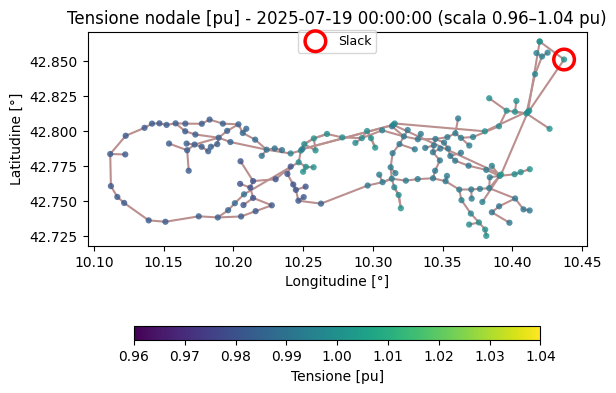

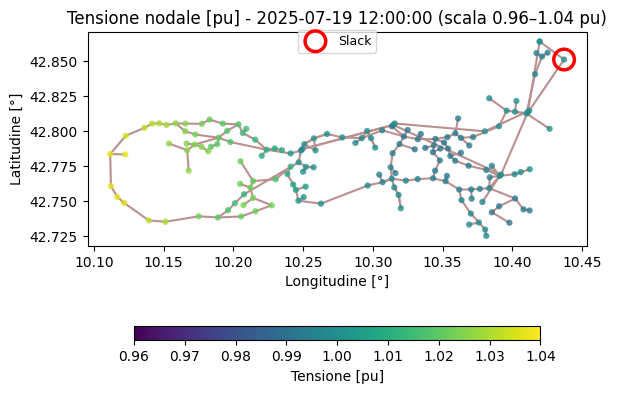

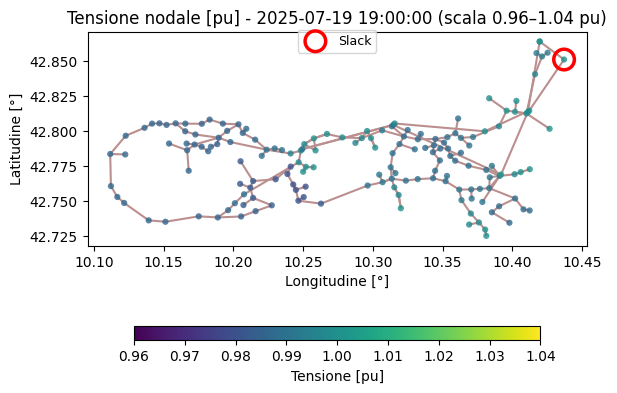

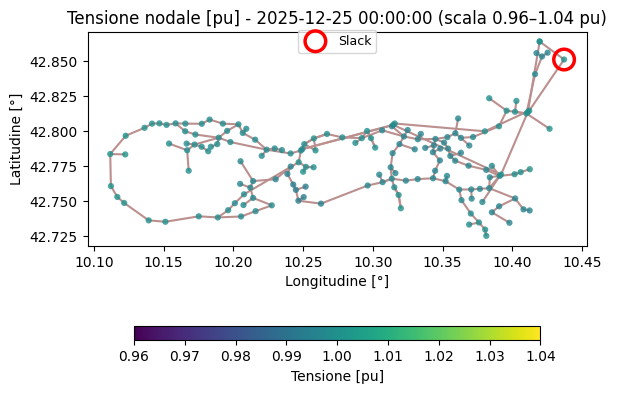

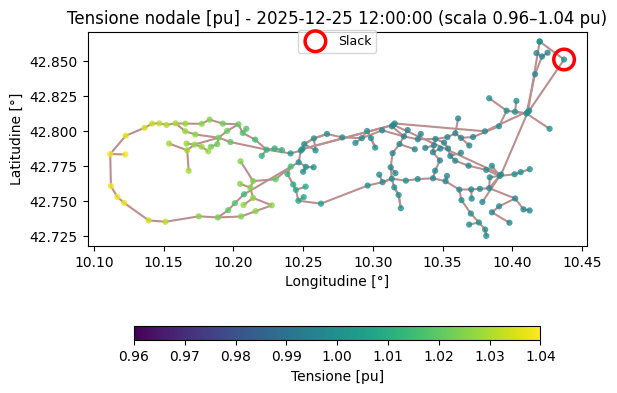

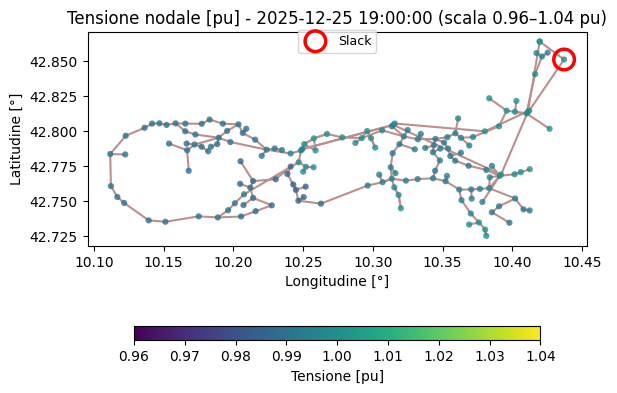

In [57]:
vmin = 0.96
vmax = 1.04

BUS_SLACK = ["microgrid_1_bus_124"]

highlight = {
    "Slack": {
        "buses": BUS_SLACK,
        "edgecolor": "red",
        "marker": "o",
        "s": 220,
        "lw": 2.5,
    },
}

for sns in n_mod.snapshots:
    v = n_mod.buses_t.v_mag_pu.loc[sns].reindex(n_mod.buses.index)

    fig, ax = plot_buses_map(
        n_mod, v,
        vmin=vmin, vmax=vmax,
        cbar_label="Tensione [pu]",
        cbar_orientation="horizontal",
        highlight=highlight
    )

    ax.set_title(f"Tensione nodale [pu] - {sns} (scala {vmin}–{vmax} pu)")
    plt.show()

SCENARIO 2: DIMENSIONAMENTO BATTERIA

In [ ]:
# Nodi con EV + BESS
ev_buses = [
    "microgrid_1_bus_76",
    "microgrid_1_bus_126",
    "microgrid_1_bus_43",
    "microgrid_1_bus_105",
]

ev_buses = [b for b in ev_buses if b in n_mod.buses.index]

if len(ev_buses) == 0:
    raise ValueError("Nessun nodo EV presente nella rete.")


# Dimensionamento BESS

# Potenza FV locale assunta per ciascun nodo
P_FV_KWP = 50.0

# Produzione media giornaliera FV da PVGIS
E_GIORNO_KWH_PER_KWP = 2.5

# Energia FV giornaliera per nodo
E_FV_GIORNO_KWH = P_FV_KWP * E_GIORNO_KWH_PER_KWP   # 125 kWh/giorno

# Parametri batteria
DOD = 0.90
ETA_BATT = 0.95

# Capacità nominale batteria
E_BESS_NOM_KWH = E_FV_GIORNO_KWH / (DOD * ETA_BATT)
E_BESS_NOM_MWH = E_BESS_NOM_KWH / 1000

# Energia utile effettivamente gestita nel ciclo giornaliero
E_BESS_UTILE_KWH = E_FV_GIORNO_KWH

# Durate operative
ORE_SCARICA = 14.0   # 19:00 - 09:00
ORE_CARICA = 10.0    # 09:00 - 19:00

# Potenze operative coerenti con l'energia disponibile
P_BESS_SCARICA_KW = E_BESS_UTILE_KWH / ORE_SCARICA
P_BESS_CARICA_KW = E_BESS_UTILE_KWH / ORE_CARICA

P_BESS_SCARICA_MW = P_BESS_SCARICA_KW / 1000
P_BESS_CARICA_MW = P_BESS_CARICA_KW / 1000

# Potenza nominale BESS assunta pari alla massima potenza richiesta
P_BESS_KW = max(P_BESS_SCARICA_KW, P_BESS_CARICA_KW)
P_BESS_MW = P_BESS_KW / 1000

print("=== Dimensionamento BESS per nodo ===")
print(f"Potenza FV locale           = {P_FV_KWP:.1f} kWp")
print(f"Energia FV giornaliera      = {E_FV_GIORNO_KWH:.1f} kWh/giorno")
print(f"DOD                         = {DOD:.2f}")
print(f"Rendimento batteria         = {ETA_BATT:.2f}")
print(f"Capacità nominale BESS      = {E_BESS_NOM_KWH:.1f} kWh")
print(f"Energia utile BESS          = {E_BESS_UTILE_KWH:.1f} kWh")
print(f"Durata scarica              = {ORE_SCARICA:.1f} h")
print(f"Durata carica               = {ORE_CARICA:.1f} h")
print(f"Potenza scarica BESS        = {P_BESS_SCARICA_KW:.1f} kW")
print(f"Potenza carica BESS         = {P_BESS_CARICA_KW:.1f} kW")
print(f"Potenza nominale BESS       = {P_BESS_KW:.1f} kW")


# Aggiunta batterie come generatori
for bus in ev_buses:
    bess_name = f"{bus}_BESS"

    if bess_name in n_mod.generators.index:
        n_mod.remove("Generator", bess_name)

    n_mod.add(
        "Generator",
        bess_name,
        bus=bus,
        carrier="battery",
        p_nom=P_BESS_MW,
        p_set=0.0,
        control="PQ"
    )


# Inizializzazione time series

for bess_name in [f"{bus}_BESS" for bus in ev_buses]:

    if bess_name not in n_mod.generators_t.p_set.columns:
        n_mod.generators_t.p_set[bess_name] = 0.0

    if bess_name not in n_mod.generators_t.q_set.columns:
        n_mod.generators_t.q_set[bess_name] = 0.0


# Profilo operativo BESS

# Convenzione PyPSA:
# P > 0 = scarica, immissione in rete
# P < 0 = carica, assorbimento dalla rete

for snap in n_mod.snapshots:
    hour = pd.Timestamp(snap).hour

    if 9 <= hour < 19:
        # ore diurne: carica distribuita su 10 ore
        p_bess = -P_BESS_CARICA_MW
        control = "PQ"

    else:
        # ore serali/notturne: scarica distribuita su 14 ore
        p_bess = P_BESS_SCARICA_MW
        control = "PV"

    for bus in ev_buses:
        bess_name = f"{bus}_BESS"

        n_mod.generators_t.p_set.loc[snap, bess_name] = p_bess
        n_mod.generators_t.q_set.loc[snap, bess_name] = 0.0

        n_mod.generators.loc[bess_name, "control"] = control

        # Setpoint tensione del nodo per generatori in PV
        if "v_mag_pu_set" not in n_mod.buses.columns:
            n_mod.buses["v_mag_pu_set"] = 1.0

        n_mod.buses.loc[bus, "v_mag_pu_set"] = 1.0

# Risultati complessivi
print("\n=== BESS aggiunti alla rete ===")
print(f"Nodi con BESS                = {len(ev_buses)}")
print(f"Potenza scarica per nodo     = {P_BESS_SCARICA_MW:.4f} MW")
print(f"Potenza carica per nodo      = {P_BESS_CARICA_MW:.4f} MW")
print(f"Potenza nominale per nodo    = {P_BESS_MW:.4f} MW")
print(f"Capacità BESS per nodo       = {E_BESS_NOM_MWH:.3f} MWh")
print(f"Potenza totale BESS          = {P_BESS_MW * len(ev_buses):.3f} MW")
print(f"Capacità totale BESS         = {E_BESS_NOM_MWH * len(ev_buses):.3f} MWh")

LOGICA DI CONTROLLO SCENARIO 2

In [ ]:
# SCENARIO 2 - ESTATE CON FV + BESS NEI NODI EV
# Logica di controllo:
# 09:00-19:00  -> FV in PV, BESS in carica PQ
# 19:00-09:00  -> FV in PQ, BESS in scarica PV
# Snapshot analizzati: 00:00, 12:00, 19:00 del 19 luglio
# 1) NODI EV + BESS
ev_buses = [
    "microgrid_1_bus_76",
    "microgrid_1_bus_126",
    "microgrid_1_bus_43",
    "microgrid_1_bus_105",
]

ev_buses = [b for b in ev_buses if b in n_mod.buses.index]

if len(ev_buses) == 0:
    raise ValueError("Nessun nodo EV presente nella rete.")

# 2) SNAPSHOT ESTIVI

summer_snaps = [
    pd.Timestamp("2025-07-19 00:00:00"),
    pd.Timestamp("2025-07-19 12:00:00"),
    pd.Timestamp("2025-07-19 19:00:00"),
]

summer_snaps = [s for s in summer_snaps if s in pd.DatetimeIndex(n_mod.snapshots)]

if len(summer_snaps) == 0:
    raise ValueError("Nessuno snapshot estivo presente in n_mod.snapshots.")


# 3) PARAMETRI DI CONTROLLO
slack_name = "grid_import_microgrid_1_bus_124"

VM_SET_PU = 1.00
CF_19 = 0.15


# 4) DIMENSIONAMENTO BESS ENERGETICAMENTE COERENTE
# Potenza FV locale assunta per ciascun nodo
P_FV_KWP = 50.0

# Producibilità media giornaliera specifica
E_GIORNO_KWH_PER_KWP = 2.5

# Energia FV giornaliera producibile per nodo
E_FV_GIORNO_KWH = P_FV_KWP * E_GIORNO_KWH_PER_KWP   # 125 kWh/giorno

# Parametri batteria
DOD = 0.90
ETA_BATT = 0.95

# Capacità nominale BESS
E_BESS_NOM_KWH = E_FV_GIORNO_KWH / (DOD * ETA_BATT)
E_BESS_NOM_MWH = E_BESS_NOM_KWH / 1000

# Energia utile effettivamente gestita nel ciclo giornaliero
E_BESS_UTILE_KWH = E_FV_GIORNO_KWH

# Durate operative
ORE_SCARICA = 14.0   # 19:00 - 09:00
ORE_CARICA = 10.0    # 09:00 - 19:00

# Potenze coerenti con l'energia disponibile
P_BESS_SCARICA_KW = E_BESS_UTILE_KWH / ORE_SCARICA
P_BESS_CARICA_KW = E_BESS_UTILE_KWH / ORE_CARICA

P_BESS_SCARICA_MW = P_BESS_SCARICA_KW / 1000
P_BESS_CARICA_MW = P_BESS_CARICA_KW / 1000

# Potenza nominale BESS assunta pari alla massima potenza richiesta
P_BESS_KW = max(P_BESS_SCARICA_KW, P_BESS_CARICA_KW)
P_BESS_MW = P_BESS_KW / 1000

# Profilo operativo BESS
P_BESS_00_MW = P_BESS_SCARICA_MW       # scarica
P_BESS_12_MW = -P_BESS_CARICA_MW       # carica
P_BESS_19_MW = P_BESS_SCARICA_MW       # scarica

# DataFrame riepilogativo
bess_df = pd.DataFrame(index=ev_buses)

bess_df["P_FV_nom_kWp"] = P_FV_KWP
bess_df["E_FV_giorno_kWh"] = E_FV_GIORNO_KWH
bess_df["E_BESS_nom_kWh"] = E_BESS_NOM_KWH
bess_df["E_BESS_utile_kWh"] = E_BESS_UTILE_KWH
bess_df["P_BESS_nom_MW"] = P_BESS_MW
bess_df["P_BESS_00_MW"] = P_BESS_00_MW
bess_df["P_BESS_12_MW"] = P_BESS_12_MW
bess_df["P_BESS_19_MW"] = P_BESS_19_MW

print("=== DIMENSIONAMENTO BESS PER NODO ===")
print(f"Potenza FV locale           = {P_FV_KWP:.1f} kWp")
print(f"Energia FV giornaliera      = {E_FV_GIORNO_KWH:.1f} kWh/giorno")
print(f"DOD                         = {DOD:.2f}")
print(f"Rendimento batteria         = {ETA_BATT:.2f}")
print(f"Capacità nominale BESS      = {E_BESS_NOM_KWH:.1f} kWh")
print(f"Energia utile BESS          = {E_BESS_UTILE_KWH:.1f} kWh")
print(f"Durata scarica              = {ORE_SCARICA:.1f} h")
print(f"Durata carica               = {ORE_CARICA:.1f} h")
print(f"Potenza scarica BESS        = {P_BESS_SCARICA_KW:.1f} kW")
print(f"Potenza carica BESS         = {P_BESS_CARICA_KW:.1f} kW")
print(f"Potenza nominale BESS       = {P_BESS_KW:.1f} kW")

print("\n=== TOTALI BESS ===")
print(f"Nodi con BESS               = {len(ev_buses)}")
print(f"Potenza totale BESS         = {P_BESS_MW * len(ev_buses):.3f} MW")
print(f"Capacità totale BESS        = {E_BESS_NOM_MWH * len(ev_buses):.3f} MWh")

print("\n=== TABELLA BESS ===")
print(bess_df)


# 5) FUNZIONE COSTRUZIONE SCENARIO

def build_scenario_network(base_net, snapshot, vm_set_pu=1.00):

    net = base_net.copy(with_time=False)
    net.set_snapshots([snapshot])

    net.generators_t.p_set = pd.DataFrame(
        0.0, index=net.snapshots, columns=net.generators.index
    )
    net.generators_t.q_set = pd.DataFrame(
        0.0, index=net.snapshots, columns=net.generators.index
    )

    net.loads_t.p_set = pd.DataFrame(
        0.0, index=net.snapshots, columns=net.loads.index
    )
    net.loads_t.q_set = pd.DataFrame(
        0.0, index=net.snapshots, columns=net.loads.index
    )

    if hasattr(base_net.loads_t, "p_set") and snapshot in base_net.loads_t.p_set.index:
        cols = net.loads.index.intersection(base_net.loads_t.p_set.columns)
        net.loads_t.p_set.loc[snapshot, cols] = (
            base_net.loads_t.p_set.loc[snapshot, cols].astype(float)
        )

    if hasattr(base_net.loads_t, "q_set") and snapshot in base_net.loads_t.q_set.index:
        cols = net.loads.index.intersection(base_net.loads_t.q_set.columns)
        net.loads_t.q_set.loc[snapshot, cols] = (
            base_net.loads_t.q_set.loc[snapshot, cols].astype(float)
        )

    if hasattr(base_net.generators_t, "p_set") and snapshot in base_net.generators_t.p_set.index:
        cols = net.generators.index.intersection(base_net.generators_t.p_set.columns)
        net.generators_t.p_set.loc[snapshot, cols] = (
            base_net.generators_t.p_set.loc[snapshot, cols].astype(float)
        )

    if hasattr(base_net.generators_t, "q_set") and snapshot in base_net.generators_t.q_set.index:
        cols = net.generators.index.intersection(base_net.generators_t.q_set.columns)
        net.generators_t.q_set.loc[snapshot, cols] = (
            base_net.generators_t.q_set.loc[snapshot, cols].astype(float)
        )

    if "control" not in net.generators.columns:
        net.generators["control"] = "PQ"

    if "v_mag_pu_set" not in net.buses.columns:
        net.buses["v_mag_pu_set"] = 1.0

    net.buses["v_mag_pu_set"] = 1.0
    net.generators.loc[net.generators.index != slack_name, "control"] = "PQ"
    net.generators_t.q_set.loc[:, :] = 0.0

  
    # Aggiunta BESS nei nodi EV
    for bus in ev_buses:
        bess_name = f"BESS_{bus}"

        if bess_name not in net.generators.index:
            net.add(
                "Generator",
                name=bess_name,
                bus=bus,
                p_nom=P_BESS_MW,
                carrier="battery",
                control="PQ"
            )

    net.generators_t.p_set = net.generators_t.p_set.reindex(
        columns=net.generators.index,
        fill_value=0.0
    )

    net.generators_t.q_set = net.generators_t.q_set.reindex(
        columns=net.generators.index,
        fill_value=0.0
    )


    # Logica di controllo per snapshot
   
    hour = snapshot.hour

    for bus in ev_buses:

        bess_name = f"BESS_{bus}"

        bus_pv = list(net.generators.index[
            (net.generators.carrier == "solar") &
            (net.generators.bus == bus)
        ])

        # 00:00 - FV spento, BESS in scarica PV
        if hour == 0:

            for g in bus_pv:
                net.generators.loc[g, "control"] = "PQ"
                net.generators_t.p_set.loc[snapshot, g] = 0.0
                net.generators_t.q_set.loc[snapshot, g] = 0.0

            net.generators.loc[bess_name, "control"] = "PV"
            net.generators_t.p_set.loc[snapshot, bess_name] = P_BESS_00_MW
            net.generators_t.q_set.loc[snapshot, bess_name] = 0.0
            net.buses.loc[bus, "v_mag_pu_set"] = vm_set_pu

        # 12:00 - FV in PV, BESS in carica PQ
        elif hour == 12:

            for g in bus_pv:
                net.generators.loc[g, "control"] = "PV"
                net.buses.loc[bus, "v_mag_pu_set"] = vm_set_pu

            net.generators.loc[bess_name, "control"] = "PQ"
            net.generators_t.p_set.loc[snapshot, bess_name] = P_BESS_12_MW
            net.generators_t.q_set.loc[snapshot, bess_name] = 0.0

        # 19:00 - FV al 15%, BESS in scarica PV
        elif hour == 19:

            for g in bus_pv:
                p_nom_pv = float(net.generators.loc[g, "p_nom"])
                net.generators.loc[g, "control"] = "PQ"
                net.generators_t.p_set.loc[snapshot, g] = CF_19 * p_nom_pv
                net.generators_t.q_set.loc[snapshot, g] = 0.0

            net.generators.loc[bess_name, "control"] = "PV"
            net.generators_t.p_set.loc[snapshot, bess_name] = P_BESS_19_MW
            net.generators_t.q_set.loc[snapshot, bess_name] = 0.0
            net.buses.loc[bus, "v_mag_pu_set"] = vm_set_pu

        else:
            raise ValueError(f"Snapshot {snapshot} non previsto.")

    return net


# 6) POWER FLOW
scenario_results = []
bus_voltage_results = []
gen_summary_results = []

for sns in summer_snaps:

    print(f"\n================ SNAPSHOT {sns} ================")

    net_s = build_scenario_network(
        base_net=n_mod,
        snapshot=sns,
        vm_set_pu=VM_SET_PU
    )

    net_s.lpf(snapshots=[sns])
    pf_res = net_s.pf(snapshots=[sns], use_seed=True)

    converged = bool(pf_res["converged"].loc[sns].any())

    row = {
        "snapshot": sns,
        "converged": converged
    }

    if slack_name in net_s.generators.index:
        row["P_slack_MW"] = float(net_s.generators_t.p.loc[sns, slack_name])
        row["Q_slack_MVAr"] = float(net_s.generators_t.q.loc[sns, slack_name])

    if converged:
        v = net_s.buses_t.v_mag_pu.loc[sns]
        row["Vmin"] = float(v.min())
        row["Vmax"] = float(v.max())

    scenario_results.append(row)

    summary_rows = []

    for bus in ev_buses:

        bus_pv = list(net_s.generators.index[
            (net_s.generators.carrier == "solar") &
            (net_s.generators.bus == bus)
        ])

        bess_name = f"BESS_{bus}"

        p_fv_set = (
            float(net_s.generators_t.p_set.loc[sns, bus_pv].sum())
            if len(bus_pv) > 0 else 0.0
        )

        q_fv = (
            float(net_s.generators_t.q.loc[sns, bus_pv].sum())
            if converged and len(bus_pv) > 0 else np.nan
        )

        p_bess_set = float(net_s.generators_t.p_set.loc[sns, bess_name])

        q_bess = (
            float(net_s.generators_t.q.loc[sns, bess_name])
            if converged else np.nan
        )

        summary_rows.append({
            "bus": bus,
            "P_FV_set_MW": p_fv_set,
            "Q_FV_MVAr": q_fv,
            "FV_control": ",".join(
                net_s.generators.loc[bus_pv, "control"].astype(str).tolist()
            ) if len(bus_pv) > 0 else "",
            "P_BESS_set_MW": p_bess_set,
            "Q_BESS_MVAr": q_bess,
            "BESS_control": str(net_s.generators.loc[bess_name, "control"]),
            "V_set_pu": float(net_s.buses.loc[bus, "v_mag_pu_set"]),
            "V_bus_pu": (
                float(net_s.buses_t.v_mag_pu.loc[sns, bus])
                if converged else np.nan
            )
        })

        gen_summary_results.append({
            "snapshot": sns,
            **summary_rows[-1]
        })

        if converged:
            bus_voltage_results.append({
                "snapshot": sns,
                "bus": bus,
                "v_mag_pu": float(net_s.buses_t.v_mag_pu.loc[sns, bus])
            })

    df_summary = pd.DataFrame(summary_rows).set_index("bus")

    print("\n--- Stato FV / BESS nei nodi EV ---")
    print(df_summary)


# 7) DATAFRAME FINALI

df_scenarios = pd.DataFrame(scenario_results).set_index("snapshot")
df_bus_v = pd.DataFrame(bus_voltage_results).set_index(["snapshot", "bus"])
df_gen_summary = pd.DataFrame(gen_summary_results).set_index(["snapshot", "bus"])

print("\n================ RISULTATI SCENARI ================")
print(df_scenarios)

print("\n================ TENSIONI NODI EV ================")
print(df_bus_v)

print("\n================ RIEPILOGO FV/BESS ================")
print(df_gen_summary)

GRAFICO CARICA/SCARICA BATTERIA

In [ ]:
# PROFILO GIORNALIERO BESS - LOGICA FV + BESS
# 09:00-19:00  -> BESS in carica
# 19:00-09:00  -> BESS in scarica
# Convenzione:
# P > 0  scarica  -> immissione in rete
# P < 0  carica   -> assorbimento dalla rete/FV


# Potenze BESS
P_SCARICA_KW = 8.9
P_CARICA_KW = 12.5

P_SCARICA_MW = P_SCARICA_KW / 1000
P_CARICA_MW = P_CARICA_KW / 1000

# Intervallo temporale giornaliero
start = pd.Timestamp("2025-07-19 00:00")
end = pd.Timestamp("2025-07-20 00:00")

time_index = pd.date_range(start=start, end=end, freq="15min")

# Profilo potenza BESS
p_bess = []

for t in time_index:
    hour = t.hour + t.minute / 60

    if 9 <= hour < 19:
        # carica
        p_bess.append(-P_CARICA_MW)
    else:
        # scarica
        p_bess.append(P_SCARICA_MW)

df_bess_profile = pd.DataFrame(
    {"P_BESS_MW": p_bess},
    index=time_index
)

# GRAFICO
plt.figure(figsize=(10, 5))

plt.step(
    df_bess_profile.index,
    df_bess_profile["P_BESS_MW"],
    where="post",
    linewidth=2,
    label="Potenza BESS"
)

plt.axhline(0, linestyle="--", linewidth=1)

# Annotazioni
plt.scatter(pd.Timestamp("2025-07-19 00:00"), P_SCARICA_MW)
plt.text(
    pd.Timestamp("2025-07-19 00:00"),
    P_SCARICA_MW,
    "scarica",
    va="bottom"
)

plt.scatter(pd.Timestamp("2025-07-19 09:00"), -P_CARICA_MW)
plt.text(
    pd.Timestamp("2025-07-19 09:00"),
    -P_CARICA_MW,
    "carica",
    va="top"
)

plt.scatter(pd.Timestamp("2025-07-19 19:00"), P_SCARICA_MW)
plt.text(
    pd.Timestamp("2025-07-19 19:00"),
    P_SCARICA_MW,
    "scarica",
    va="bottom"
)

plt.title("Profilo giornaliero BESS - configurazione 146 kWh")
plt.xlabel("Ora")
plt.ylabel("Potenza BESS [MW]")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

POWER FLOW SCENARIO 2

In [ ]:
for sns in summer_snaps:

    print("\n====================")
    print("Snapshot:", sns)

    # costruisci rete scenario
    net_s = build_scenario_network(n_mod, sns, vm_set_pu=VM_SET_PU)

    # inizializzazione
    net_s.lpf(snapshots=[sns])

    # power flow AC
    res = net_s.pf(snapshots=[sns], use_seed=True)

    conv = bool(res["converged"].loc[sns].any())
    print("PF convergence:", conv)

In [ ]:
# Vmin / Vmax PER OGNI SNAPSHOT - SCENARIO FV + BESS

for sns in summer_snaps:

    # costruisci rete scenario
    net_s = build_scenario_network(n_mod, sns, vm_set_pu=VM_SET_PU)

    # power flow
    net_s.lpf(snapshots=[sns])
    net_s.pf(snapshots=[sns], use_seed=True)

    # tensioni
    v = net_s.buses_t.v_mag_pu.loc[sns].dropna()

    print(f"\n=== Snapshot {sns} ===")
    print("Vmin:", float(v.min()), "bus:", v.idxmin())
    print("Vmax:", float(v.max()), "bus:", v.idxmax())

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_buses_map(
    n, bvalue,
    vmin=None, vmax=None,
    cmap_name="viridis",
    cbar_label="",
    cbar_orientation="horizontal",
    highlight=None,   # dict: {"label": {"buses":[...], "edgecolor":"...", "marker":"...", "s":..., "lw":...}}
):
    bvalue = bvalue.reindex(n.buses.index)

    if vmin is None:
        vmin = float(bvalue.min())
    if vmax is None:
        vmax = float(bvalue.max())

    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    bus_colors = bvalue.map(lambda x: mpl.colors.to_hex(cmap(norm(x))))

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    n.plot(
        ax=ax,
        bus_sizes=0.000005,
        bus_colors=bus_colors,
        bus_alpha=0.8,
    )

    ax.set_xlabel("Longitudine [°]")
    ax.set_ylabel("Latitudine [°]")
    ax.set_axis_on()

    # Colorbar
    if cbar_orientation == "horizontal":
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="horizontal",
            pad=0.08,
            fraction=0.03,
            shrink=0.85,
            aspect=30
        )
    else:
        cbar = fig.colorbar(
            sm, ax=ax,
            orientation="vertical",
            pad=0.04,
            fraction=0.046,
            shrink=0.9
        )

    if cbar_label:
        cbar.set_label(cbar_label)

    # Evidenzia bus: solo cerchi/marker
    if highlight:
        x = n.buses["x"]
        y = n.buses["y"]

        for lbl, spec in highlight.items():
            buses = [b for b in spec.get("buses", []) if b in n.buses.index]
            if not buses:
                continue

            edgecolor = spec.get("edgecolor", "red")
            marker    = spec.get("marker", "o")
            s         = spec.get("s", 160)
            lw        = spec.get("lw", 2.5)

            ax.scatter(
                x.loc[buses], y.loc[buses],
                s=s,
                facecolors="none",
                edgecolors=edgecolor,
                linewidths=lw,
                marker=marker,
                zorder=6,
                label=lbl
            )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncol=len(highlight),
            frameon=True,
            fontsize=9
        )

    return fig, ax

In [ ]:
vmin = 0.96
vmax = 1.04

BUS_SLACK = ["microgrid_1_bus_124"]

highlight = {
    "Slack": {
        "buses": BUS_SLACK,
        "edgecolor": "red",
        "marker": "o",
        "s": 220,
        "lw": 2.5,
    }
}

scenario_networks = {}

for sns in summer_snaps:

    # costruzione rete scenario FV + BESS
    net_s = build_scenario_network(n_mod, sns, vm_set_pu=VM_SET_PU)

    # power flow
    net_s.lpf(snapshots=[sns])
    pf_res = net_s.pf(snapshots=[sns], use_seed=True)

    scenario_networks[sns] = net_s

    converged = bool(pf_res["converged"].loc[sns].any())

    if not converged:
        print(f"⚠️ Power flow non convergente per {sns}")
        continue

    # tensioni
    v = net_s.buses_t.v_mag_pu.loc[sns].reindex(net_s.buses.index)

    # plot
    fig, ax = plot_buses_map(
        net_s,
        v,
        vmin=vmin,
        vmax=vmax,
        cmap_name="viridis",
        cbar_label="Tensione [pu]",
        cbar_orientation="horizontal",
        highlight=highlight
    )

    ax.set_title(f"Tensione nodale [pu] - scenario FV+BESS - {sns}")
    plt.show()